## 1. What this notebook computes

Notebook 17a showed that no recorded Kohn-Sham state of dirac16complex is an
admissible source of the author's metric: the states fail the three source
conditions C1, C2, C3 of the $a_4$ equations. This notebook asks WHY, and the
answer is the **conservation law** of energy and momentum. Every source of the
field equations must be conserved; the Kohn-Sham states obey the conservation law
of the hidden direction at every point, and the energy law of the time direction
only for the total energy of the patch; and for a conserved source the conditions
take a very simple form. The notebook

- checks that the Kohn-Sham source is built on the author's eight REAL
  $16 \times 16$ gamma matrices (the very file that the Rust solver read);
- derives with sympy the conservation law of a source in the author's metric, in
  the coordinate $x_8$ and in the hidden coordinate $y$, and compares it with the
  Revision records;
- PROVES that for a conserved source the violation of C2 is the slope of $p_8$:
  $p_3 + p_t - 2p_8 = p_8'(y)/(3H)$; so C2 holds exactly where $p_8$ is flat;
- PROVES that the time derivative of the constraint equation is $3a_4'$ times the
  evolution equation, so that the linear member $a_4 = AHx_4$ needs $p_3 = p_t$;
- tests these identities on the 75 recorded Kohn-Sham ground states: point by
  point (with a convergence study of the differences), integrated over the
  hidden direction, and along the deflating history, where only the energy of the
  whole patch obeys the time law;
- averages the source over the hidden direction, shows that the averaged C2 still
  fails, and integrates the averaged $a_4$ equations of Einstein gravity with
  their first integral (an APPROXIMATION, as the Revision record states);
- draws six teaching plots. It takes about twenty seconds.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 17b (The conservation laws and the source conditions: why the Kohn-Sham states
fail) is the file `Revision/textbook/notebooks/17b_conserved_sources.ipynb` of the
repository Dirac_claude. It checks that the Kohn-Sham source of chapter 17 rests on the
eight real 16 x 16 gamma matrices of the author (the very file the Rust solver read),
derives with sympy the conservation law of a source in the author's metric, in the
coordinate x8 and in the hidden coordinate y, and compares it with the Revision records.
It proves that for a conserved source the violation p3 + p_t - 2 p8 of condition C2
equals the slope of p8 along y divided by 3H, and that the time derivative of the
constraint is 3 a4' times the evolution equation, so that the linear member needs p3 =
p_t. It then tests these identities on the 75 recorded Kohn-Sham ground states: point by
point with fourth-order differences and a convergence study, integrated with the brane
and tip values, and along the deflating history with Simpson's rule. The Kohn-Sham states
obey the conservation law of the hidden direction at every point and the energy law of
the time direction for the total energy of the patch (not point by point), and still fail
the source conditions. Finally it averages the source over the hidden direction and
integrates the averaged a4 equations of Einstein gravity with their first integral, an
approximation whose numbers it checks against the Revision record. Six teaching plots. It
needs a computer with Windows 11, macOS or Linux, an internet connection for the
installation, the program Git, and Python 3.12 or newer (the notebooks were built with
Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0,
mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2,
ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, sympy and
matplotlib; the other packages run Jupyter, the program that shows and runs notebooks. It
does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 17b_conserved_sources.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 20 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 17b_conserved_sources.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
17b_conserved_sources.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/17b.captions.json`
- `Revision/textbook/figures/17b_1_eight_gammas.png`
- `Revision/textbook/figures/17b_2_slope_identity.png`
- `Revision/textbook/figures/17b_3_difference_order.png`
- `Revision/textbook/figures/17b_4_brane_and_mean.png`
- `Revision/textbook/figures/17b_5_energy_exchange.png`
- `Revision/textbook/figures/17b_6_first_integral.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS every figure file of this notebook exists
    ALL 20 CHECKS PASSED (notebook 17b)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/17b_conserved_sources.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" naming gammas.json, a report or a profile file: the notebook reads
  the Revision records of the repository. Run it inside the folder
  Revision/textbook/notebooks of a complete copy of the repository made with git clone,
  not on a copy of the notebook file alone.
- the check of the sha256 fingerprint of gammas.json fails: the file was changed, for
  example by an editor or a tool that converted its line endings. Restore it with the
  command below, run in the repository folder.

      git checkout HEAD Revision/algebra/gammas.json

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 17b (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 17b (The conservation laws and the source conditions: why the Kohn-Sham states
# fail) is the file Revision/textbook/notebooks/17b_conserved_sources.ipynb of the
# repository Dirac_claude. It checks that the Kohn-Sham source of chapter 17 rests on the
# eight real 16 x 16 gamma matrices of the author (the very file the Rust solver read),
# derives with sympy the conservation law of a source in the author's metric, in the
# coordinate x8 and in the hidden coordinate y, and compares it with the Revision
# records. It proves that for a conserved source the violation p3 + p_t - 2 p8 of
# condition C2 equals the slope of p8 along y divided by 3H, and that the time derivative
# of the constraint is 3 a4' times the evolution equation, so that the linear member
# needs p3 = p_t. It then tests these identities on the 75 recorded Kohn-Sham ground
# states: point by point with fourth-order differences and a convergence study,
# integrated with the brane and tip values, and along the deflating history with
# Simpson's rule. The Kohn-Sham states obey the conservation law of the hidden direction
# at every point and the energy law of the time direction for the total energy of the
# patch (not point by point), and still fail the source conditions. Finally it averages
# the source over the hidden direction and integrates the averaged a4 equations of
# Einstein gravity with their first integral, an approximation whose numbers it checks
# against the Revision record. Six teaching plots. It needs a computer with Windows 11,
# macOS or Linux, an internet connection for the installation, the program Git, and
# Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these packages
# at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
# jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
# 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
# Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 17b_conserved_sources.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 20
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 17b_conserved_sources.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 17b_conserved_sources.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/17b.captions.json
# - Revision/textbook/figures/17b_1_eight_gammas.png
# - Revision/textbook/figures/17b_2_slope_identity.png
# - Revision/textbook/figures/17b_3_difference_order.png
# - Revision/textbook/figures/17b_4_brane_and_mean.png
# - Revision/textbook/figures/17b_5_energy_exchange.png
# - Revision/textbook/figures/17b_6_first_integral.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS every figure file of this notebook exists
#     ALL 20 CHECKS PASSED (notebook 17b)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/17b_conserved_sources.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" naming gammas.json, a report or a profile file: the notebook
#   reads the Revision records of the repository. Run it inside the folder
#   Revision/textbook/notebooks of a complete copy of the repository made with git clone,
#   not on a copy of the notebook file alone.
# - the check of the sha256 fingerprint of gammas.json fails: the file was changed, for
#   example by an editor or a tool that converted its line endings. Restore it with the
#   command below, run in the repository folder.
#     git checkout HEAD Revision/algebra/gammas.json
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "17b"  # this notebook: chapter 17, example b


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 17b complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinates** (the author's names): $x_1, x_2, x_3$ = ordinary 3-space,
  which inflates (scale factor $e^{a_4}\sin^{1/6}z$); $x_4$ = the time;
  $x_5, x_6, x_7$ = the three **extra times**, which **deflate exponentially**
  (scale factor $e^{-a_4}\sin^{1/6}z$, with $a_4$ increasing); $x_8$ = the hidden
  space direction, $z = 6Hx_8$ between $0$ and $\pi/2$.
- **Hidden coordinate** $y = \ln(\sin z)/(6H)$: another way to number the points
  of the hidden direction; $y = 0$ is the **brane** ($z = \pi/2$), $y = -3$ the
  **tip cutoff** of the computations. A **chart** is a choice of coordinates.
- **Gamma matrices** $\gamma^{(x_1)}, \dots, \gamma^{(x_8)}$: eight square tables
  of numbers with $\gamma^a\gamma^b + \gamma^b\gamma^a = 2\eta^{ab}\,1$ (the
  **Clifford relation**), $\eta = \mathrm{diag}(+1,+1,+1,-1,-1,-1,-1,+1)$. The
  author's are real $16 \times 16$ **signed permutation matrices**: each row and
  each column holds exactly one nonzero entry, $+1$ or $-1$.
- **sha256 fingerprint**: a 64-digit code computed from the bytes of a file; two
  files with the same fingerprint are, for all practical purposes, identical.
- **Energy-momentum tensor** $T^\mu{}_\nu$ (the **source**): here
  $T = \mathrm{diag}(p_3, p_3, p_3, -\rho, p_t, p_t, p_t, p_8)$ in the order
  $x_1, \dots, x_8$, with energy density $\rho$ and pressures $p_3$ (3-space),
  $p_t$ (extra times), $p_8$ (hidden direction); possibly mixed entries $q_{48}$
  (row $x_4$, column $x_8$) and $q_{84}$.
- **Christoffel symbols** $\Gamma^\lambda{}_{\mu\nu} = \tfrac12 g^{\lambda\kappa}
  (\partial_\mu g_{\kappa\nu} + \partial_\nu g_{\kappa\mu} -
  \partial_\kappa g_{\mu\nu})$: numbers built from the first derivatives of the
  metric that say how the coordinate directions turn from point to point.
- **Covariant divergence** $\nabla_\mu T^\mu{}_\nu = \partial_\mu T^\mu{}_\nu +
  \Gamma^\mu{}_{\mu\lambda}T^\lambda{}_\nu - \Gamma^\lambda{}_{\mu\nu}
  T^\mu{}_\lambda$ (sum over repeated indices): the curved-space version of "what
  flows out of a small box". The **conservation law** is
  $\nabla_\mu T^\mu{}_\nu = 0$ for every $\nu$.
- **Bianchi identity**: the left-hand sides of the Einstein-Lovelock equations
  have zero covariant divergence for EVERY metric; hence every source of the
  equations must be conserved.
- **Source conditions** (from the $a_4$ equations): **C1** no component of the
  source depends on $x_8$ and $q_{48} = q_{84} = 0$; **C2** $p_3 + p_t = 2p_8$;
  **C3** for the linear member $a_4 = AHx_4 + a_0$: $p_3 = p_t = p_8$ and a
  constant $\rho$. **Admissible source**: one that meets them.
- **Constraint** (the $x_4$ equation, no $a_4''$) and **evolution equation**
  ($a_4''\,F(a_4') = \kappa(p_3 - p_t)$) of the $a_4$ equations.
- **Finite difference** of fourth order: the slope of a tabulated function from
  five neighbouring values,
  $f'(y) \approx [-f(y+2h) + 8f(y+h) - 8f(y-h) + f(y-2h)]/(12h)$; its error falls
  like $h^4$ when the step $h$ shrinks (**order of accuracy** 4).
- **Simpson's rule**: the integral of a function over $[a, a+2h]$ is about
  $(h/3)[f(a) + 4f(a+h) + f(a+2h)]$; error like $h^4$.
- **Weighted mean**: $\int e^{6Hy}p_8\,dy / \int e^{6Hy}dy$, the average of
  $p_8$ over the proper volume.
- **Kohn-Sham state**, **slice** $a_{4,0}$, **history** $a_4 = AHx_4$ with
  $A = 1$, **prescribed background**, **test field**, **back-reaction**: as in
  Notebook 17a; a state name such as `N136_lamp2_a20` means $N = 136$,
  $\lambda = +\lambda_2$, $a_{4,0} = 2.0$.
- **Least squares**: the straight line through a set of points that makes the sum
  of the squared vertical distances of the points from the line as small as
  possible.
- **Weighted average over the hidden direction** $\bar X$ (also called the
  **moment** of $X$): the integral of $e^{6Hy}X$ over the patch divided by the
  integral of $e^{6Hy}$. A **moment equation** is a field equation multiplied by
  $e^{6Hy}$ and integrated over the patch.
- **First integral**: an equation with only first derivatives that every solution
  of a second-order equation obeys; here $a_4'^2$ as a function of $a_4$.
- **Cubic Hermite interpolation**: between two tabulated points, the cubic
  polynomial with the given values AND the given slopes at both ends.
- **Turning point**: the value of $a_4$ where $a_4'$ reaches $0$; there the
  deflation of the extra times halts.
- **Status labels**: PROVED (exact), COMPUTED (numerical, with its measured
  error), ASSUMED (including a stated approximation), OPEN. Units: $H = 1$,
  $m = 1$.

## 4. The physical and mathematical situation

The field equations of gravity, $\sum_k\alpha_kE_{(k)}{}^\mu{}_\nu +
\Lambda\delta^\mu_\nu = \kappa T^\mu{}_\nu$, have a left-hand side whose covariant
divergence vanishes identically (the Bianchi identity; the Revision record checks
it for all three Lovelock tensors of the author's metric). Taking the divergence
of both sides gives $\kappa\nabla_\mu T^\mu{}_\nu = 0$: a source must be
conserved. Conservation is therefore NECESSARY. This notebook shows that it is not
SUFFICIENT, and that it explains the failure of the Kohn-Sham states.

The Kohn-Sham states are computed in the prescribed background $a_4 = Hx_4$ (the
extra times deflate as $e^{-a_4}$, 3-space inflates as $e^{a_4}$). A field that
solves its own TIME-DEPENDENT field equation in a given metric has a conserved
energy-momentum tensor. The Kohn-Sham states are not such solutions: each one
solves the instantaneous problem of one slice (the stationary-slice ansatz). So
the Revision record proves less, and exactly this: the conservation law of the
hidden direction for every self-consistent state, at every point; and the
energy-change law of the time direction only INTEGRATED over the hidden
direction, for the instantaneous states followed with fixed occupations (they
carry no energy flux along $y$). The Rust solver checks both numerically. We will
see:

1. in the hidden direction, conservation reads
   $p_8' + 6Hp_8 = 3H(p_3 + p_t)$ (the prime is $d/dy$); hence the violation of
   C2 is $V = p_3 + p_t - 2p_8 = p_8'/(3H)$. For a conserved source without mixed
   entries, C2 and "$p_8$ does not depend on $x_8$" (part of C1) are the SAME
   condition. The Kohn-Sham $p_8$ changes by orders of magnitude along $y$, so C2
   must fail;
2. in the time direction, conservation reads $\rho' = -3a_4'(p_3 - p_t)$ (the
   prime is $d/dx_4$): energy flows between the source and the expanding and
   deflating directions unless $p_3 = p_t$. The Kohn-Sham gas has
   $p_3 > 0 = p_t$ (at $\lambda = 0$), so its energy must change along the
   history, which C3 forbids. For the Kohn-Sham states this law holds for the
   energy of the whole patch but fails point by point (section 12).

## 5. The Revision records and the helpers that read them

The next cell imports the packages and names the Revision records used below. It
defines four helpers: `read_json` reads a JSON file of the repository,
`record_entry` finds a check by its name in a Revision report, `reproduces` is
a check that passes only when this notebook's own result holds AND the named
checks of the report have the verdict PASS, and `tex_number` writes a number in
powers of ten for the captions. Then it counts the checks of the seven reports and
requires that all of them passed.

In [2]:
import csv  # reads tables stored as CSV files (comma-separated values)
import hashlib  # computes the sha256 fingerprint of a file

import numpy as np  # arrays of numbers
import sympy as sp  # exact algebra with symbols

GAMMAS = "Revision/algebra/gammas.json"  # the eight real 16 x 16 gammas
ALGEBRA = "Revision/algebra/reports/python-algebra.json"  # their checks
EQUATIONS = "Revision/field_equations_a4/a4-equations.json"  # the a4 equations
PY_A4 = "Revision/field_equations_a4/reports/python-a4-report.json"  # sympy
WL_A4 = "Revision/field_equations_a4/reports/wolfram-a4-report.json"  # Wolfram
SOURCE_REPORT = "Revision/field_equations_a4/reports/ks-source-conditions.json"
KS_SOURCE = "Revision/field_equations_a4/ks_source/reports/ks-source-a4.json"
KS_THEORY = "Revision/kohn_sham/ks-theory.json"  # the Kohn-Sham theory record
KS_PY = "Revision/kohn_sham/reports/ks-theory-python.json"  # its sympy checks
KS_RUST = "Revision/kohn_sham/reports/ks-rust-solver.json"  # the solver checks
GROUND = "Revision/kohn_sham/results/ground"  # the 75 Kohn-Sham ground states


def read_json(relative):
    """Read a JSON file of the repository (a Revision record)."""
    return json.loads(repository_file(relative).read_text(encoding="utf-8"))


def record_entry(report_file, name):
    """The entry {name, verdict, detail} of a check of a report, None if absent."""
    for entry in read_json(report_file)["checks"]:
        if entry["name"] == name:
            return entry
    return None


def reproduces(condition, name, report_file, record_names):
    """A check that also requires the named checks of the report to be PASS."""
    found = all((record_entry(report_file, n) or {}).get("verdict", "").upper()
                == "PASS" for n in record_names)  # some reports write "pass"
    names_text = ", ".join(record_names)  # the check names, separated by commas
    check(condition and found, name, record=f"{report_file}, check {names_text}")


def tex_number(value, digits=2):
    """A number for a caption in powers of ten: 0.0123 -> 1.2 \\times 10^{-2}."""
    mantissa, exponent = f"{value:.{digits - 1}e}".split("e")
    return f"{mantissa} \\times 10^{{{int(exponent)}}}"


REPORTS = [ALGEBRA, PY_A4, WL_A4, SOURCE_REPORT, KS_SOURCE, KS_PY, KS_RUST]
every_pass = True
for report_file in REPORTS:
    verdicts = [entry["verdict"].upper()
                for entry in read_json(report_file)["checks"]]
    passed = verdicts.count("PASS")  # how many checks of this report passed
    every_pass = every_pass and passed == len(verdicts)
    report(report_file.split("/")[-1], f"{passed} of {len(verdicts)} checks PASS")
check(every_pass, "every check of the seven Revision reports used here is PASS")

RESULT python-algebra.json = 35 of 35 checks PASS
RESULT python-a4-report.json = 63 of 63 checks PASS
RESULT wolfram-a4-report.json = 52 of 52 checks PASS
RESULT ks-source-conditions.json = 5 of 5 checks PASS
RESULT ks-source-a4.json = 23 of 23 checks PASS
RESULT ks-theory-python.json = 58 of 58 checks PASS
RESULT ks-rust-solver.json = 42 of 42 checks PASS
PASS every check of the seven Revision reports used here is PASS


## 6. The eight real $16 \times 16$ gamma matrices behind the Kohn-Sham source

dirac16complex is a 16-component spinor field, and its field equation, its
Lagrangian and its energy-momentum tensor are written with the author's eight
real $16 \times 16$ gamma matrices. The Kohn-Sham solver reduces the 16-component
equation to $2 \times 2$ blocks; the solver's own check `block_reduction_numeric`
confirms that its blocks are exactly the 16-component Hamiltonian written in
another basis. The next cell reads the matrices from the Revision record
`gammas.json` and checks: there are eight; each is $16 \times 16$; every entry is
a JSON integer (so the matrices are REAL) equal to $-1$, $0$ or $+1$; each is a
signed permutation matrix.

In [3]:
gamma_record = read_json(GAMMAS)
entries = [v for matrix in gamma_record["gamma"] for row in matrix for v in row]
real_integers = all(isinstance(v, int) for v in entries)  # no complex entries
gamma = [np.array(matrix, dtype=float) for matrix in gamma_record["gamma"]]
eta = np.array(gamma_record["eta"], dtype=float)  # +1 or -1 for x1, ..., x8
shapes = sorted({matrix.shape for matrix in gamma})  # should be one shape only
values = sorted({int(v) for v in entries})  # the entries that occur
one_per_line = all(np.all(np.count_nonzero(matrix, axis=0) == 1)
                   and np.all(np.count_nonzero(matrix, axis=1) == 1)
                   for matrix in gamma)  # one nonzero entry per row and column
report("number of gamma matrices", len(gamma))
report("their shapes", shapes)
report("the entries that occur", values)
report("eta in the order x1, ..., x8", [int(v) for v in eta])
reproduces(len(gamma) == 8 and shapes == [(16, 16)] and real_integers
           and values == [-1, 0, 1] and one_per_line,
           "eight real 16 x 16 signed permutation matrices",
           ALGEBRA, ["reality_signed_permutations"])

RESULT number of gamma matrices = 8
RESULT their shapes = [(16, 16)]
RESULT the entries that occur = [-1, 0, 1]
RESULT eta in the order x1, ..., x8 = [1, 1, 1, -1, -1, -1, -1, 1]
PASS eight real 16 x 16 signed permutation matrices
     reproduces Revision/algebra/reports/python-algebra.json, check
    reality_signed_permutations


The next cell checks the Clifford relation
$\gamma^a\gamma^b + \gamma^b\gamma^a = 2\eta^{ab}\,1$ for all $8 \times 8 = 64$
ordered pairs $(a, b)$ (the products of integer matrices are exact in floating
point), and it computes the sha256 fingerprint of the file `gammas.json`. The Rust
solver printed the first 16 digits of the fingerprint of the file it read into
its check `gamma_fixture_numeric`; equal digits show that the Kohn-Sham states
were computed with exactly these matrices.

In [4]:
identity16 = np.eye(16)  # the 16 x 16 unit matrix
deviation = 0.0  # the largest deviation from the Clifford relation
for a in range(8):
    for b in range(8):
        anticommutator = gamma[a] @ gamma[b] + gamma[b] @ gamma[a]
        target = 2.0 * eta[a] * identity16 if a == b else 0.0 * identity16
        deviation = max(deviation, float(np.max(np.abs(anticommutator - target))))
report("largest deviation from the Clifford relation, 64 pairs", deviation)
reproduces(deviation == 0.0, "the Clifford relation holds exactly for all 64 pairs",
           ALGEBRA, ["clifford_relation"])
fingerprint = hashlib.sha256(repository_file(GAMMAS).read_bytes()).hexdigest()
report("sha256 of gammas.json, first 16 digits", fingerprint[:16])
solver_detail = record_entry(KS_RUST, "gamma_fixture_numeric")["detail"]
reproduces(f"(sha256 {fingerprint[:16]})" in solver_detail,
           "the Rust Kohn-Sham solver read exactly this file of gammas",
           KS_RUST, ["gamma_fixture_numeric", "block_reduction_numeric"])

RESULT largest deviation from the Clifford relation, 64 pairs = 0.0
PASS the Clifford relation holds exactly for all 64 pairs
     reproduces Revision/algebra/reports/python-algebra.json, check clifford_relation
RESULT sha256 of gammas.json, first 16 digits = 95d8cbdd0682fd30
PASS the Rust Kohn-Sham solver read exactly this file of gammas
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    gamma_fixture_numeric, block_reduction_numeric


The next cell draws the eight matrices as coloured tables (heat maps): red is
$+1$, blue is $-1$, white is $0$. The title of each panel says which coordinate
the matrix belongs to and the sign of its square, $(\gamma^a)^2 = \eta^{aa}\,1$.

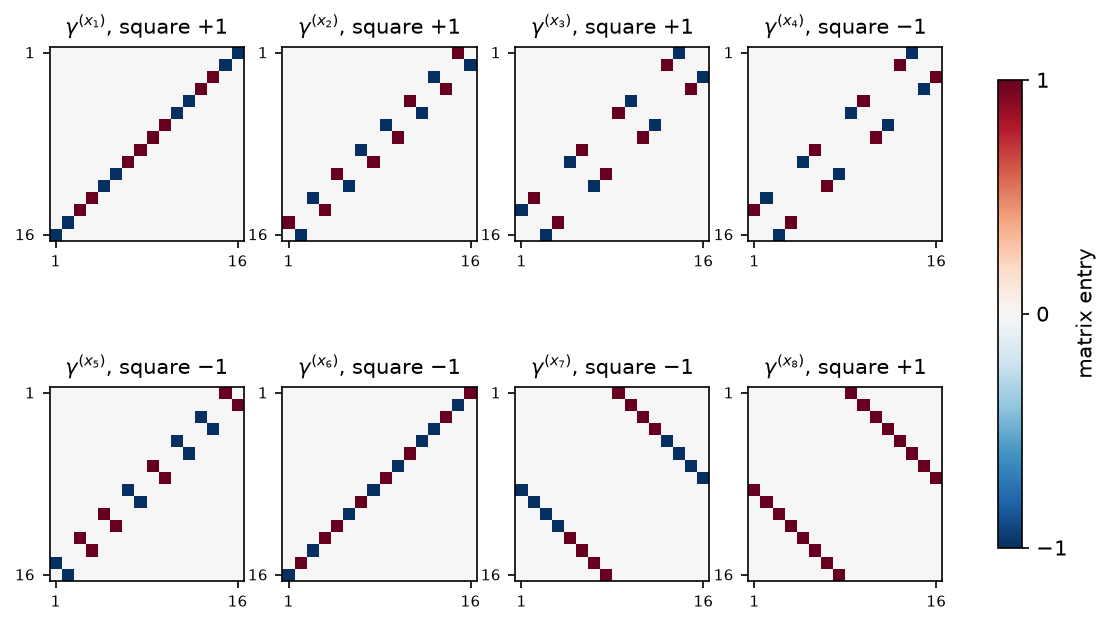

Figure 17b.1 saved as Revision/textbook/figures/17b_1_eight_gammas.png


In [5]:
LABELS = ["x_1", "x_2", "x_3", "x_4", "x_5", "x_6", "x_7", "x_8"]
fig, axes = plt.subplots(2, 4, figsize=(9.6, 5.4))
for a, ax in enumerate(axes.flat):
    image = ax.imshow(gamma[a], cmap="RdBu_r", vmin=-1.0, vmax=1.0)
    sign = "+1" if eta[a] > 0 else "-1"  # the square of this gamma matrix
    ax.set_title(f"$\\gamma^{{({LABELS[a]})}}$, square ${sign}$", fontsize=10)
    ax.set_xticks([0, 15], ["1", "16"])  # column numbers 1 and 16
    ax.set_yticks([0, 15], ["1", "16"])  # row numbers 1 and 16
    ax.tick_params(labelsize=7)  # small numbers, so that they do not collide
    ax.grid(False)  # no grid lines over the entries
fig.colorbar(image, ax=axes, shrink=0.75, label="matrix entry", ticks=[-1, 0, 1])
nonzero_count = int(sum(np.count_nonzero(matrix) for matrix in gamma))
save_figure(fig, "eight_gammas",
            "The author's eight real $16 \\times 16$ gamma matrices "
            "$\\gamma^{(x_1)}$ to $\\gamma^{(x_8)}$ as heat maps (rows 1 to 16 down, "
            "columns 1 to 16 across; red $+1$, blue $-1$, white $0$). Each row and "
            "each column holds exactly one nonzero entry, so the eight matrices "
            f"have {nonzero_count} nonzero entries in all; the squares are $+1$ "
            "for the space-like directions $x_1, x_2, x_3, x_8$ and $-1$ for the "
            "time $x_4$ and the deflating extra times $x_5, x_6, x_7$. These are "
            "the matrices with which the Kohn-Sham source of this chapter was "
            "computed.")

## 7. The hidden coordinate $y$

The author's metric has $g_{88} = \cot^2 z$ with $z = 6Hx_8$, and the warp factor
$\sin^{1/3}z$ in front of the six directions $x_1, x_2, x_3, x_5, x_6, x_7$. The
Kohn-Sham computations use $y = \ln(\sin z)/(6H)$ instead of $x_8$. The next cell
derives, step by step with sympy:

1. $dy/dx_8 = \cot z$ (the chain rule: $d\ln(\sin z)/dz = \cot z$ and
   $dz/dx_8 = 6H$);
2. $g_{yy} = g_{88}\,(dx_8/dy)^2 = \cot^2 z/\cot^2 z = 1$: $y$ measures proper
   length along the hidden direction;
3. $\sin z = e^{6Hy}$, so the warp factor is $\sin^{1/3}z = e^{2Hy}$;
4. $\sqrt{|\det g|} = \cos z$ in the $x_8$ chart and $e^{6Hy}$ in the $y$ chart
   (the factors $e^{\pm 2a_4}$ of 3-space and of the extra times cancel in the
   determinant: the 7-volume does not change while 3-space inflates and the
   extra times deflate).

To let sympy simplify powers safely, $\sin z$ and $\cos z$ are written as
positive symbols $s$ and $c$ (both are positive for $0 < z < \pi/2$).

In [6]:
H = sp.symbols("H", positive=True)  # the constant H of the metric
X8 = sp.symbols("x8", positive=True)  # the author's hidden coordinate
z = 6 * H * X8  # the angle z = 6 H x8
y_of_x8 = sp.log(sp.sin(z)) / (6 * H)  # the hidden coordinate y
dy_dx8 = sp.simplify(sp.diff(y_of_x8, X8))  # chain rule
g_yy = sp.simplify(sp.cot(z) ** 2 / dy_dx8 ** 2)  # g88 times (dx8/dy)^2
say(f"dy/dx8 = {dy_dx8},  g_yy = {g_yy}")
s, c, a4_value = sp.symbols("s c a4", positive=True)  # s = sin z, c = cos z
y_of_s = sp.log(s) / (6 * H)  # y written with s = sin z
warp = sp.simplify(sp.exp(2 * H * y_of_s))  # e^{2Hy} in terms of s
say(f"e^(2Hy) = {warp}  (the warp factor sin^(1/3) z)")
factors = ([sp.exp(2 * a4_value) * s ** sp.Rational(1, 3)] * 3 + [1]
           + [sp.exp(-2 * a4_value) * s ** sp.Rational(1, 3)] * 3)  # |g_ii|, i < 8
root_x8 = sp.simplify(sp.sqrt(sp.prod(factors) * (c / s) ** 2))  # g88 = cot^2 z
root_y = sp.simplify(sp.sqrt(sp.prod(factors) * 1))  # g_yy = 1
say(f"sqrt|det g| in the x8 chart = {root_x8};  in the y chart = {root_y}")
reproduces(sp.simplify(dy_dx8 - sp.cot(z)) == 0 and g_yy == 1
           and warp == s ** sp.Rational(1, 3) and root_x8 == c and root_y == s,
           "dy/dx8 = cot z, g_yy = 1, sin^(1/3) z = e^(2Hy), sqrt|g| = cos z or e^(6Hy)",
           KS_PY, ["geometry_hidden_coordinate", "geometry_sqrt_det",
                   "geometry_warped_form"])

dy/dx8 = 1/tan(6*H*x8),  g_yy = 1
e^(2Hy) = s**(1/3)  (the warp factor sin^(1/3) z)
sqrt|det g| in the x8 chart = c;  in the y chart = s
PASS dy/dx8 = cot z, g_yy = 1, sin^(1/3) z = e^(2Hy), sqrt|g| = cos z or e^(6Hy)
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    geometry_hidden_coordinate, geometry_sqrt_det, geometry_warped_form


## 8. The conservation law of a source in the author's metric

The next cell defines two helpers that work for any diagonal metric:
`christoffel` computes all $8 \times 8 \times 8 = 512$ Christoffel symbols with
the formula of section 3, and `divergence` computes the eight components
$\nabla_\mu T^\mu{}_\nu$, $\nu = 1, \dots, 8$, of the covariant divergence of a
table $T^\mu{}_\nu$ (stored as `T[mu, nu]`). It then builds the author's metric in
the $x_8$ chart with a general function $a_4(x_4)$, and the most general source
the $a_4$ record allows: $\rho, p_3, p_t, p_8, q_{48}, q_{84}$, each a function of
$x_4$ and $x_8$. Finally it prints the eight components of the divergence, written
in the record's notation: `ad1` is $a_4'$, `d4rho` is $\partial\rho/\partial x_4$,
`d8p8` is $\partial p_8/\partial x_8$, `cc` is $\cot z$, and so on (the helper
`readable` collects the terms of each source quantity and simplifies the factor in
front of it with $\sin 2z = 2\sin z\cos z$ and $\tan z = \sin z/\cos z$).

In [7]:
def christoffel(metric, chart):
    """All Gamma^l_{mn} of a diagonal metric, as a nested list [l][m][n]."""
    inverse = [1 / metric[k, k] for k in range(8)]  # diagonal: g^kk = 1 / g_kk
    return [[[sp.simplify(inverse[l] * (sp.diff(metric[l, m], chart[n])
                                        + sp.diff(metric[l, n], chart[m])
                                        - sp.diff(metric[m, n], chart[l])) / 2)
              for n in range(8)] for m in range(8)] for l in range(8)]


def divergence(T, metric, chart):
    """The 8 components nabla_mu T^mu_nu of a table T[mu, nu] = T^mu_nu."""
    G = christoffel(metric, chart)
    result = []
    for nu in range(8):
        total = 0
        for mu in range(8):
            total += sp.diff(T[mu, nu], chart[mu])  # d_mu T^mu_nu
            for lam in range(8):
                total += G[mu][mu][lam] * T[lam, nu]  # Gamma^mu_{mu lam} T^lam_nu
                total -= G[lam][mu][nu] * T[mu, lam]  # Gamma^lam_{mu nu} T^mu_lam
        result.append(sp.simplify(total))
    return result


coords = sp.symbols("x1:9", real=True)  # x1, ..., x8 (the x8 chart)
x4, x8 = coords[3], coords[7]
a4 = sp.Function("a4")(x4)  # the free function of the metric
zz = 6 * H * x8  # z = 6 H x8
wz = sp.sin(zz) ** sp.Rational(1, 3)  # the warp factor sin^(1/3) z
metric_x8 = sp.diag(*([sp.exp(2 * a4) * wz] * 3 + [-1]
                      + [-sp.exp(-2 * a4) * wz] * 3 + [sp.cot(zz) ** 2]))
names = ("rho", "p3", "pt", "p8", "q48", "q84")
rho, p3, pt, p8, q48, q84 = (sp.Function(n)(x4, x8) for n in names)
T_x8 = sp.diag(p3, p3, p3, -rho, pt, pt, pt, p8)  # the diagonal part
T_x8[3, 7] = q48  # T^x4_x8
T_x8[7, 3] = q84  # T^x8_x4
div_x8 = divergence(T_x8, metric_x8, coords)
notation = {sp.Derivative(f, v): sp.Symbol(f"d{v.name[1]}{f.func.__name__}")
            for f in (rho, p3, pt, p8, q48, q84) for v in (x4, x8)}
notation[sp.Derivative(a4, x4)] = sp.Symbol("ad1")  # a4'


def in_record_notation(expression):
    """Write derivatives as d4rho, d8p8, ... and functions as plain symbols."""
    expression = expression.subs(notation)
    return expression.subs({f: sp.Symbol(f.func.__name__)
                            for f in (rho, p3, pt, p8, q48, q84)})


cc = sp.Symbol("cc")  # the record writes cot z as cc


def readable(expression):
    """A component as a sum of source symbols times simplified coefficients."""
    plain = sp.expand(in_record_notation(expression))
    sources = sorted(plain.free_symbols - {H, x8, sp.Symbol("ad1")}, key=str)
    total = sp.Integer(0)  # the sum, built term by term
    for symbol, factor in sp.collect(plain, sources, evaluate=False).items():
        factor = factor.subs(sp.sin(2 * zz), 2 * sp.sin(zz) * sp.cos(zz))
        factor = sp.simplify(factor.subs(sp.tan(zz), sp.sin(zz) / sp.cos(zz)))
        factor = sp.simplify(factor.subs(sp.sin(zz), sp.cos(zz) / cc))
        total += factor * symbol  # sin z = cos z / cot z
    return total.subs(sp.tan(zz), 1 / cc)


for nu, component in enumerate(div_x8):
    say(f"nabla_mu T^mu_x{nu + 1} = {readable(component)}")

nabla_mu T^mu_x1 = 0
nabla_mu T^mu_x2 = 0
nabla_mu T^mu_x3 = 0
nabla_mu T^mu_x4 = -6*H*q84/cc - 3*ad1*p3 + 3*ad1*pt - d4rho + d8q84
nabla_mu T^mu_x5 = 0
nabla_mu T^mu_x6 = 0
nabla_mu T^mu_x7 = 0
nabla_mu T^mu_x8 = -3*H*cc*p3 + 6*H*cc*p8 - 3*H*cc*pt + d4q48 + d8p8


Six of the eight components vanish identically. The two others are the
conservation laws in the time direction $x_4$ and in the hidden direction $x_8$.
The next cell reads the record's two equations `conservation_x4` and
`conservation_x8` (Wolfram Language text; `cc` stands for $\cot z$) and checks
that they equal ours (the difference is rewritten with cosines and simplified to
zero; one term needs the identity $\tan z + \cot z = 2/\sin 2z$).

In [8]:
equations = read_json(EQUATIONS)
RECORD_NAMES = {"ad1": sp.Derivative(a4, x4), "H": H, "cc": sp.cot(zz),
                "rho": rho, "p3": p3, "pt": pt, "p8": p8, "q48": q48, "q84": q84}
RECORD_NAMES.update({str(symbol): derivative
                     for derivative, symbol in notation.items()})


def record_equation(text):
    """An equation left == right of the record as the expression left - right."""
    left, right = text.replace("^", "**").split("==")
    return (sp.sympify(left, locals=RECORD_NAMES)
            - sp.sympify(right, locals=RECORD_NAMES))


same = []
for key, nu in (("conservation_x4", 3), ("conservation_x8", 7)):
    recorded = record_equation(equations["generalSource"][key]["input"])
    difference = sp.simplify((div_x8[nu] - recorded).rewrite(sp.cos))
    same.append(difference == 0)
    say(f"{key}: ours minus the record = {difference}")
zero_components = all(div_x8[nu] == 0 for nu in (0, 1, 2, 4, 5, 6))
reproduces(all(same) and zero_components,
           "our divergence equals the record: x4 and x8 laws, six zero components",
           PY_A4, ["conservation_components", "json_conservation"])

conservation_x4: ours minus the record = 0
conservation_x8: ours minus the record = 0
PASS our divergence equals the record: x4 and x8 laws, six zero components
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    conservation_components, json_conservation


## 9. The conservation law in the coordinate $y$, and what it does to C2

The Kohn-Sham states have $q_{48} = q_{84} = 0$ (their mixed component vanishes
for every eigen-orbital) and depend on $y$. In the $y$ chart the author's metric
is, by section 7,
$e^{2Hy}[e^{2a_4}(dx_1^2 + dx_2^2 + dx_3^2) - e^{-2a_4}(dx_5^2 + dx_6^2 +
dx_7^2)] - dx_4^2 + dy^2$. The next cell computes the covariant divergence of a
diagonal source $T(x_4, y)$ in this chart with the same helper and checks the two
surviving components against the formulas

$$\nabla_\mu T^\mu{}_{x_4} = -\partial_4\rho - 3a_4'(p_3 - p_t), \qquad
\nabla_\mu T^\mu{}_y = p_8' + 6Hp_8 - 3H(p_3 + p_t)$$

of the Kohn-Sham theory record (the prime on $p_8$ is $\partial/\partial y$). It
prints the components with short names: `ad1` is $a_4'$, `d4rho` is
$\partial\rho/\partial x_4$ and `dyp8` is $\partial p_8/\partial y$.

In [9]:
yc = sp.symbols("y", real=True)  # the hidden coordinate y
chart_y = list(coords[:7]) + [yc]  # x1, ..., x7, y
wy = sp.exp(2 * H * yc)  # the warp factor e^{2Hy} = sin^(1/3) z
metric_y = sp.diag(*([sp.exp(2 * a4) * wy] * 3 + [-1]
                     + [-sp.exp(-2 * a4) * wy] * 3 + [1]))
RHO, P3, PT, P8 = (sp.Function(n)(x4, yc) for n in ("rho", "p3", "pt", "p8"))
T_y = sp.diag(P3, P3, P3, -RHO, PT, PT, PT, P8)  # a diagonal source T(x4, y)
div_y = divergence(T_y, metric_y, chart_y)
law_x4 = -sp.diff(RHO, x4) - 3 * sp.diff(a4, x4) * (P3 - PT)
law_y = sp.diff(P8, yc) + 6 * H * P8 - 3 * H * (P3 + PT)
derivatives = {sp.Derivative(RHO, x4): sp.Symbol("d4rho"),
               sp.Derivative(P8, yc): sp.Symbol("dyp8"),
               sp.Derivative(a4, x4): sp.Symbol("ad1")}  # short names
functions = {f: sp.Symbol(f.func.__name__) for f in (RHO, P3, PT, P8)}


def short(expression):
    """Write the derivatives as d4rho, dyp8, ad1 and the functions as symbols."""
    return expression.subs(derivatives).subs(functions)


say(f"nabla_mu T^mu_x4 = {short(div_y[3])}")
say(f"nabla_mu T^mu_y = {short(div_y[7])}")
others_zero = all(div_y[nu] == 0 for nu in (0, 1, 2, 4, 5, 6))
theory = read_json(KS_THEORY)["emt"]  # the energy-momentum part of the record
say("ks-theory.json, emt.conservationY: " + theory["conservationY"])
reproduces(sp.simplify(div_y[3] - law_x4) == 0 and sp.simplify(div_y[7] - law_y) == 0
           and others_zero
           and "6H p8 = 3H (p3 + p_t)" in theory["conservationY"],
           "in the y chart: the x4 law and dp8/dy + 6H p8 = 3H (p3 + p_t)",
           KS_PY, ["emt_y_conservation_selfconsistent", "emt_x4_component"])

nabla_mu T^mu_x4 = -3*ad1*p3 + 3*ad1*pt - d4rho
nabla_mu T^mu_y = -3*H*p3 + 6*H*p8 - 3*H*pt + dyp8
ks-theory.json, emt.conservationY: p8' + 6H p8 = 3H (p3 + p_t) for every self-consistent
    state (nabla_mu T^mu_y = 0): solver check
PASS in the y chart: the x4 law and dp8/dy + 6H p8 = 3H (p3 + p_t)
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    emt_y_conservation_selfconsistent, emt_x4_component


Now the key step. Solve the $y$ law for $p_3$:
$p_3 = (p_8' + 6Hp_8)/(3H) - p_t$. Put this into the violation of C2:

$$V = p_3 + p_t - 2p_8 = \frac{p_8' + 6Hp_8}{3H} - 2p_8 = \frac{p_8'}{3H}.$$

The first equality is the definition of $V$; the second replaces $p_3 + p_t$ by
its value from the conservation law; the third cancels $6Hp_8/(3H) = 2p_8$
against $-2p_8$. So, for EVERY conserved diagonal source: **C2 holds at a point
exactly when $p_8$ is flat there.** C2 is not an extra demand on a conserved
source; it is the $p_8$ part of C1. The next cell repeats the algebra with
sympy.

In [10]:
p3_from_law = sp.solve(sp.Eq(law_y, 0), P3)[0]  # p3 from the y conservation law
V = P3 + PT - 2 * P8  # the violation of C2
V_conserved = sp.simplify(V.subs(P3, p3_from_law))
say(f"p3 from the conservation law: {short(p3_from_law)}")
say(f"V = p3 + p_t - 2 p8 for a conserved source: {short(V_conserved)}")
check(sp.simplify(V_conserved - sp.diff(P8, yc) / (3 * H)) == 0,
      "PROVED: for a conserved source V = p3 + p_t - 2 p8 = (dp8/dy) / (3H)")

p3 from the conservation law: 2*p8 - pt + dyp8/(3*H)
V = p3 + p_t - 2 p8 for a conserved source: dyp8/(3*H)
PASS PROVED: for a conserved source V = p3 + p_t - 2 p8 = (dp8/dy) / (3H)


## 10. Testing $V = p_8'/(3H)$ on the recorded Kohn-Sham states

The next cell reads the 75 profile files of the Kohn-Sham record (151 points
$y = -3, -2.98, \dots, 0$; columns `rho`, `p3`, `p_t`, `p8` among others), the
table of integrals and the parameters. It defines `slope`, the fourth-order
difference of section 3 with the step $s \cdot h$ ($h = 0.02$, $s = 1, 2, \dots$),
evaluated at the inner points (two points at each end have no neighbours on one
side). For every state with a nonzero tensor it compares $V$ with $p_8'/(3H)$ and
divides the largest difference by max|T| (the largest absolute value of $\rho$,
$p_3$, $p_t$, $p_8$ of the state).

In [11]:
COLUMNS = ("rho", "p3", "p_t", "p8")  # the four diagonal components


def read_profile(path):
    """A profile table as a dictionary: column name -> numpy array (151 values)."""
    data = np.genfromtxt(path, delimiter=",", names=True)
    return {name: data[name] for name in data.dtype.names}


files = sorted(repository_file(f"{GROUND}/profiles").glob("*.csv"),
               key=lambda path: path.name)
profiles = {path.stem: read_profile(path) for path in files}
with repository_file(f"{GROUND}/emt-integrals.csv").open(
        encoding="utf-8", newline="") as handle:
    integrals = {row["id"]: row for row in csv.DictReader(handle)}
physics = read_json("Revision/kohn_sham/results/parameters.json")["physics"]
H_value, L_cut, VOL7 = physics["H"], physics["L_tipCutoff"], physics["Vol7"]
scale = {sid: float(max(np.max(np.abs(prof[c])) for c in COLUMNS))
         for sid, prof in profiles.items()}  # max|T| of every state
nonzero = [sid for sid in profiles if scale[sid] > 0.0]
y = profiles["N136_lam0_a10"]["y"]  # the common grid of y
h = float(y[1] - y[0])  # the grid step


def slope(values, s=1):
    """dv/dy at the points i = 2s, ..., 150 - 2s (fourth order, step s h)."""
    v = values
    return (-v[4 * s:] + 8 * v[3 * s:-s] - 8 * v[s:-3 * s] + v[:-4 * s]) / (12 * h * s)


def violation(prof):
    """V(y) = p3 + p_t - 2 p8 of a profile."""
    return prof["p3"] + prof["p_t"] - 2.0 * prof["p8"]


residual = {sid: float(np.max(np.abs(slope(profiles[sid]["p8"]) / (3 * H_value)
                                      - violation(profiles[sid])[2:-2])))
            / scale[sid] for sid in nonzero}
worst = max(residual, key=residual.get)  # the state with the largest difference
report("states with a nonzero tensor", len(nonzero))
report("grid step h", f"{h:.2f}")
report("largest |(dp8/dy)/(3H) - V| / max|T| over 70 states", f"{residual[worst]:.2e}",
       f"({worst})")
check(len(nonzero) == 70 and residual[worst] < 1e-3,
      "V = (dp8/dy)/(3H) on every state to 1e-3 of max|T| (fourth-order differences)")

RESULT states with a nonzero tensor = 70
RESULT grid step h = 0.02
RESULT largest |(dp8/dy)/(3H) - V| / max|T| over 70 states = 1.05e-04 (N8_lamm1_a00)
PASS V = (dp8/dy)/(3H) on every state to 1e-3 of max|T| (fourth-order differences)


The next cell draws the identity for the history $N = 136$, $\lambda = 0$. Left:
$p_8(y)$ at the five slices (divided by max|T|): for C2, by section 9, these
curves would have to be horizontal. Right: $V(y)$ (lines) and $p_8'(y)/(3H)$
(dots, every fifth grid point) of the slice $a_{4,0} = 1$. Both vertical axes are
symmetric logarithmic (logarithmic for large positive and negative values,
linear near zero), so that both signs and many orders of magnitude are visible.

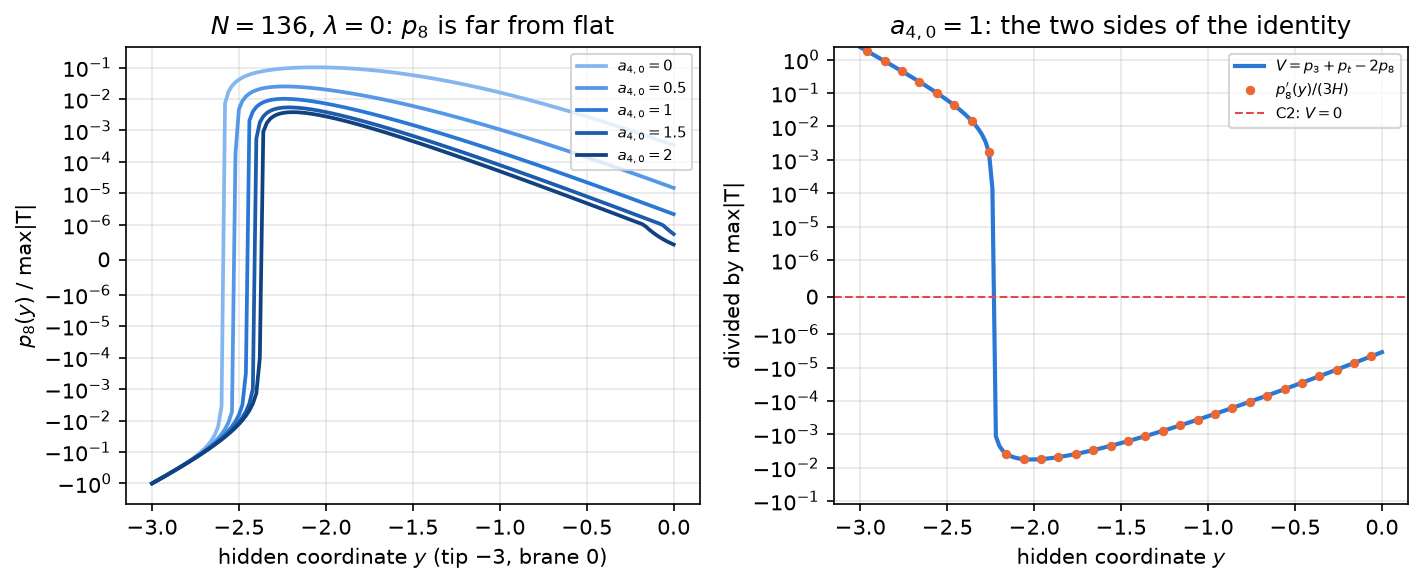

Figure 17b.2 saved as Revision/textbook/figures/17b_2_slope_identity.png


In [12]:
SLICES = {"a00": 0.0, "a05": 0.5, "a10": 1.0, "a15": 1.5, "a20": 2.0}  # a4,0
SHADES = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]  # light to dark
history136 = [f"N136_lam0_{tag}" for tag in SLICES]
fig, (left, right) = plt.subplots(1, 2, figsize=(9.6, 4.0))
for shade, sid, a40 in zip(SHADES, history136, SLICES.values()):
    left.plot(y, profiles[sid]["p8"] / scale[sid], color=shade, lw=1.8,
              label=f"$a_{{4,0}} = {a40:g}$")
left.set_yscale("symlog", linthresh=1e-6)
left.set_xlabel("hidden coordinate $y$ (tip $-3$, brane $0$)")
left.set_ylabel("$p_8(y)$ / max|T|")
left.set_title("$N = 136$, $\\lambda = 0$: $p_8$ is far from flat")
left.legend(fontsize=7, loc="upper right")
example = profiles["N136_lam0_a10"]
inner = y[2:-2]  # the points where the slope is known
right.plot(y, violation(example) / scale["N136_lam0_a10"], color="#2a78d6",
           lw=2.0, label="$V = p_3 + p_t - 2p_8$")
right.plot(inner[::5], (slope(example["p8"]) / (3 * H_value))[::5]
           / scale["N136_lam0_a10"], "o", color="#eb6834", ms=3.5,
           label="$p_8'(y)/(3H)$")
right.axhline(0.0, color="#e34948", ls="--", lw=1.0, label="C2: $V = 0$")
right.set_yscale("symlog", linthresh=1e-6)
right.set_xlabel("hidden coordinate $y$")
right.set_ylabel("divided by max|T|")
right.set_title("$a_{4,0} = 1$: the two sides of the identity")
right.legend(fontsize=7, loc="upper right")
fig.tight_layout()
p8_range = [float(np.max(np.abs(profiles[s]["p8"])) / np.min(np.abs(profiles[s]["p8"])))
            for s in history136]  # how far p8 is from flat, per slice
save_figure(fig, "slope_identity",
            "Left: the hidden-direction pressure $p_8(y)$ of the Kohn-Sham states "
            "$N = 136$, $\\lambda = 0$ at the five slices $a_{4,0} = 0$ to $2$, "
            "divided by the largest component of each state (horizontal axis: the "
            "hidden coordinate $y$; vertical axis symmetric logarithmic, linear "
            "between $-10^{-6}$ and $10^{-6}$); the largest $|p_8|$ is "
            f"{min(p8_range):.0f} to ${tex_number(max(p8_range))}$ times the "
            "smallest, while "
            "condition C2 of a conserved source demands a flat $p_8$. Right: for "
            "$a_{4,0} = 1$ the violation $V = p_3 + p_t - 2p_8$ (blue line) and the "
            "slope $p_8'(y)/(3H)$ from fourth-order differences (orange dots) lie "
            "on top of each other, as the conservation law demands; the dashed "
            "line is the value $0$ that C2 needs.")

How do we know that the small differences of the last test are errors of the
finite differences and not a failure of conservation? By changing the step. The
next cell evaluates $|p_8'/(3H) - V|/\max|T|$ at the four points
$y = -2.4, -1.8, -1.2, -0.6$ (grid indices 30, 60, 90, 120) with the steps
$s \cdot h$, $s = 1, 2, 3, 5, 6$, for five states, and fits a straight line to
$\log(\text{difference})$ against $\log(\text{step})$. A fourth-order difference
of an exact identity must give the slope $4$.

N8_lamp1_a00: differences 6.9e-07, 1.1e-05, 5.8e-05, 4.8e-04, 1.0e-03;  fitted order 4.08
N136_lam0_a10: differences 4.6e-07, 7.5e-06, 3.8e-05, 3.0e-04, 6.5e-04;  fitted order
    4.04
N136_lamp2_a20: differences 5.4e-07, 8.6e-06, 4.4e-05, 3.4e-04, 7.2e-04;  fitted order
    4.02
N688_lam0_a10: differences 4.6e-07, 7.4e-06, 3.8e-05, 3.0e-04, 6.4e-04;  fitted order
    4.04
N688_lamm2_a00: differences 4.6e-07, 7.5e-06, 3.8e-05, 3.1e-04, 6.5e-04;  fitted order
    4.04
PASS the differences fall like (step)^4: they are errors of the differences


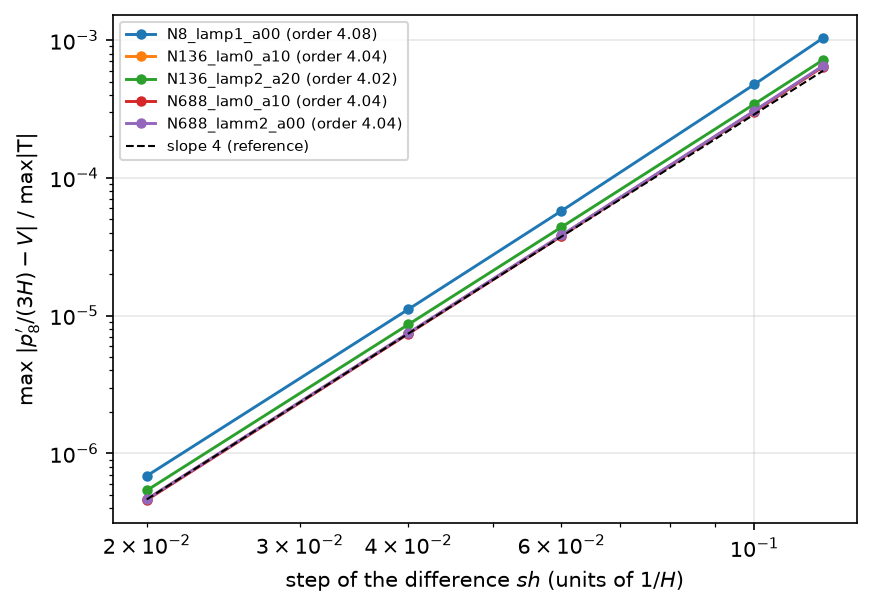

Figure 17b.3 saved as Revision/textbook/figures/17b_3_difference_order.png


In [13]:
STEPS = np.array([1, 2, 3, 5, 6])  # the step is s h
POINTS = [30, 60, 90, 120]  # grid indices of y = -2.4, -1.8, -1.2, -0.6
STUDY = ["N8_lamp1_a00", "N136_lam0_a10", "N136_lamp2_a20", "N688_lam0_a10",
         "N688_lamm2_a00"]


def difference_at_points(sid, s):
    """max over POINTS of |(dp8/dy)/(3H) - V| / max|T| with the step s h."""
    prof = profiles[sid]
    derivative = slope(prof["p8"], s) / (3 * H_value)  # index i - 2s is point i
    return max(abs(float(derivative[i - 2 * s] - violation(prof)[i]))
               for i in POINTS) / scale[sid]


errors = {sid: np.array([difference_at_points(sid, s) for s in STEPS])
          for sid in STUDY}
orders = {sid: float(np.polyfit(np.log(STEPS * h), np.log(errors[sid]), 1)[0])
          for sid in STUDY}  # the slope of the straight-line fit
for sid in STUDY:
    say(f"{sid}: differences " + ", ".join(f"{e:.1e}" for e in errors[sid])
        + f";  fitted order {orders[sid]:.2f}")
check(all(3.8 < order < 4.2 for order in orders.values()),
      "the differences fall like (step)^4: they are errors of the differences")
fig, ax = plt.subplots(figsize=(6.4, 4.4))
for sid in STUDY:
    ax.loglog(STEPS * h, errors[sid], "o-", lw=1.4, ms=4,
              label=f"{sid} (order {orders[sid]:.2f})")
reference = errors["N136_lam0_a10"][0] * (STEPS / STEPS[0]) ** 4.0
ax.loglog(STEPS * h, reference, "k--", lw=1.0, label="slope 4 (reference)")
ax.set_xlabel("step of the difference $s h$ (units of $1/H$)")
ax.set_ylabel("max $|p_8'/(3H) - V|$ / max|T|")
ax.legend(fontsize=7)
save_figure(fig, "difference_order",
            "The difference between $p_8'(y)/(3H)$, computed with fourth-order "
            "differences of step $sh$ ($h = 0.02$, $s = 1, 2, 3, 5, 6$), and the "
            "violation $V = p_3 + p_t - 2p_8$, at the four points $y = -2.4$, "
            "$-1.8$, $-1.2$, $-0.6$, divided by the largest component of the state, "
            "for five recorded Kohn-Sham states (logarithmic axes; the step in units "
            "of $1/H$). The fitted slopes lie between "
            f"{min(orders.values()):.2f} and {max(orders.values()):.2f}, the order "
            "4 of the differences: the small differences are errors of the finite "
            "differences, and the conservation law itself holds.")

## 11. The integrated form, and why the integrated ratio of C2 is not 1

Multiply the $y$ law by $e^{6Hy}$: since $(e^{6Hy}p_8)' = e^{6Hy}(p_8' + 6Hp_8)$
(product rule), the law becomes $(e^{6Hy}p_8)' = 3He^{6Hy}(p_3 + p_t)$. Integrate
from the tip $y = -L$ to the brane $y = 0$ (fundamental theorem of calculus) and
multiply by $2\,\mathrm{Vol}_7$ (the volume factor of the record's integrals):

$$2\,\mathrm{Vol}_7\left[p_8(0) - e^{-6HL}p_8(-L)\right] =
3H\left(\textstyle\int p_3 + \int p_t\right),$$

where $\int X$ means $2\,\mathrm{Vol}_7\int_{-L}^{0}e^{6Hy}X\,dy$, the column
`int_X` of the record's table. The next cell checks this with the table's brane
values, tip values and integrals for all 70 nonzero states (relative difference
of the two sides, divided by the right side). The table also has a column
`ycons_integrated_rel`: the solver's own relative difference of the same two
sides, computed from its unrounded numbers and divided by the largest of the terms
involved (not by the right side alone), so it is a close cousin of our number,
not the same number by definition; the cell checks that its largest value is the
one printed in the solver's check
`emt_y_conservation_integrated` (two mirror states, $\lambda = \pm\lambda_2$ with
$N = 8$, share this largest value; the record names one of them). Our
differences, computed from numbers printed with 16 digits, are of the same tiny
size, about $10^{-11}$.

In [14]:
def number(sid, column):
    """A number of the record's table of integrals."""
    return float(integrals[sid][column])


tip_weight = float(np.exp(-6.0 * H_value * L_cut))  # e^{-6HL}, about 1.5e-8
integrated = {}
for sid in nonzero:
    left_side = 2 * VOL7 * (number(sid, "p8_brane") - tip_weight * number(sid, "p8_tip"))
    right_side = 3 * H_value * (number(sid, "int_p3") + number(sid, "int_p_t"))
    integrated[sid] = abs(left_side - right_side) / abs(right_side)
worst_integrated = max(integrated, key=integrated.get)
report("largest relative difference of the integrated law",
       f"{integrated[worst_integrated]:.3e} ({worst_integrated})")
column = {sid: number(sid, "ycons_integrated_rel") for sid in nonzero}
column_worst = max(column, key=column.get)  # the solver's own largest value
report("largest value of the column ycons_integrated_rel",
       f"{column[column_worst]:.3e} ({column_worst})")
solver = record_entry(KS_RUST, "emt_y_conservation_integrated")["detail"]
say("the solver record: " + solver)
named = solver.split("worst value ")[1].split("(")[1].split(")")[0]  # its state
tie = abs(column[named] - column[column_worst]) < 1e-15  # mirror states tie
report("the state named by the record and its column value",
       f"{named}, {column[named]:.3e}")
reproduces(integrated[worst_integrated] < 1e-10 and tie
           and f"worst value {column[column_worst]:.3e}" in solver,
           "the integrated conservation law holds for all 70 states",
           KS_RUST, ["emt_y_conservation_integrated"])

RESULT largest relative difference of the integrated law = 1.421e-11 (N8_lamm2_a00)
RESULT largest value of the column ycons_integrated_rel = 1.422e-11 (N8_lamm2_a00)
the solver record: [e^{6Hy} p8]_{-L}^{0} = 3H int e^{6Hy} (p3 + p_t) dy (nabla_mu T^mu_y
    = 0): relative difference; 75 cases; worst value 1.422e-11 (N8_lamp2_a00); tolerance
    1.0e-7; failures: none
RESULT the state named by the record and its column value = N8_lamp2_a00, 1.422e-11
PASS the integrated conservation law holds for all 70 states
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    emt_y_conservation_integrated


Notebook 17a found that the integrated ratio $R = (\int p_3 + \int p_t)/(2\int
p_8)$ lies between about $0.1$ and $0.4$ instead of $1$. The integrated law
explains this number. Divide it by $2\int p_8$ and write $\int p_8 =
2\,\mathrm{Vol}_7\,\bar p_8\,(1 - e^{-6HL})/(6H)$, where $\bar p_8$ is the
weighted mean of $p_8$ (because $\int_{-L}^0 e^{6Hy}dy = (1 - e^{-6HL})/(6H)$):

$$R = \frac{b_8}{\bar p_8}, \qquad b_8 = \frac{p_8(0) - e^{-6HL}p_8(-L)}
{1 - e^{-6HL}}.$$

We call $b_8$ the **boundary value** of $p_8$: the brane value with the small tip
term. So the averaged C2 asks that the boundary value of $p_8$ equal its mean:
true for a flat $p_8$, false for the Kohn-Sham states. Is the tip term negligible,
so that $b_8 \approx p_8(0)$? The weight $e^{-6HL} = e^{-18}$ is tiny, but near the
tip $|p_8|$ is enormous. The next cell computes $R$ both ways for every nonzero
state, checks the record's closest value, and measures the share of $R$ that the
tip term supplies. It also measures, from the profiles, which part of the weighted
mean of $p_8$ comes from the last unit before the brane, $-1 \le y \le 0$.

In [15]:
mean_p8 = {sid: number(sid, "int_p8") / (2 * VOL7 * (1 - tip_weight) / (6 * H_value))
           for sid in nonzero}  # the weighted mean of p8
ratio = {sid: (number(sid, "int_p3") + number(sid, "int_p_t"))
         / (2 * number(sid, "int_p8")) for sid in nonzero}  # as in Notebook 17a
boundary = {sid: (number(sid, "p8_brane") - tip_weight * number(sid, "p8_tip"))
            / (1 - tip_weight) for sid in nonzero}  # the boundary value b8
from_brane = {sid: boundary[sid] / mean_p8[sid] for sid in nonzero}  # R = b8/mean
brane_only = {sid: number(sid, "p8_brane") / mean_p8[sid] for sid in nonzero}
tip_share = {sid: 1.0 - brane_only[sid] / from_brane[sid] for sid in nonzero}
step = float(y[1] - y[0])  # the grid step of y, 0.02


def simpson_rule(values):
    """Simpson's rule with the step of y (for an odd number of points)."""
    return step / 3 * (values[0] + values[-1] + 4 * values[1:-1:2].sum()
                       + 2 * values[2:-1:2].sum())


last_unit = y >= -1.0 - 1e-9  # the last unit before the brane: 51 points
near_share, table_gap = {}, {}
for sid in nonzero:
    weighted = np.exp(6 * H_value * y) * profiles[sid]["p8"]  # e^{6Hy} p8
    whole = simpson_rule(weighted)  # the integral over the whole patch
    near_share[sid] = simpson_rule(weighted[last_unit]) / whole
    table_gap[sid] = abs(2 * VOL7 * whole / number(sid, "int_p8") - 1.0)
agreement = max(abs(from_brane[sid] / ratio[sid] - 1.0) for sid in nonzero)
closest = min(ratio, key=lambda sid: abs(ratio[sid] - 1.0))
report("largest relative difference of the two forms of R", f"{agreement:.1e}")
report("R closest to 1", f"{ratio[closest]:.6g} ({closest})")
report("largest relative difference, Simpson's integral of p8 and int_p8",
       f"{max(table_gap.values()):.1e}")
for n in (8, 136, 688):
    shares = [tip_share[sid] for sid in nonzero if sid.startswith(f"N{n}_")]
    report(f"share of R from the tip term, N = {n}",
           f"{min(shares):.2g} to {max(shares):.2g}")
    nears = [near_share[sid] for sid in nonzero if sid.startswith(f"N{n}_")]
    report(f"share of the mean of p8 from -1 <= y <= 0, N = {n}",
           f"{min(nears):.3f} to {max(nears):.3f}")
detail = record_entry(SOURCE_REPORT, "ks_integrals_violate_algebraic_condition")[
    "detail"]
reproduces(agreement < 1e-9
           and f"(closest to 1: {ratio[closest]:.6g} at {closest})" in detail,
           "R = b8 / mean of p8 (b8: brane value with the tip term), 70 states",
           SOURCE_REPORT, ["ks_integrals_violate_algebraic_condition"])

RESULT largest relative difference of the two forms of R = 1.4e-11
RESULT R closest to 1 = 0.414328 (N688_lamm2_a00)
RESULT largest relative difference, Simpson's integral of p8 and int_p8 = 4.7e-09
RESULT share of R from the tip term, N = 8 = 0.31 to 0.33
RESULT share of the mean of p8 from -1 <= y <= 0, N = 8 = 0.439 to 0.441
RESULT share of R from the tip term, N = 136 = 4.1e-05 to 0.039
RESULT share of the mean of p8 from -1 <= y <= 0, N = 136 = 0.812 to 0.932
RESULT share of R from the tip term, N = 688 = 5.3e-06 to 0.025
RESULT share of the mean of p8 from -1 <= y <= 0, N = 688 = 0.816 to 0.969
PASS R = b8 / mean of p8 (b8: brane value with the tip term), 70 states
     reproduces Revision/field_equations_a4/reports/ks-source-conditions.json, check
    ks_integrals_violate_algebraic_condition


The next cell draws the boundary value $|b_8|$ against the mean $|\bar p_8|$ for
all 70 states (logarithmic axes; filled markers where $\bar p_8$ is positive,
larger open rings where it is negative). Their ratio is exactly $R$, so the
averaged C2 would put every point on the diagonal. The cell also lists the states
with a negative mean $\bar p_8$ and checks that every point lies below the
diagonal ($0 < b_8/\bar p_8 < 1$).

states with a negative mean of p8: N8_lamp1_a00, N8_lamp1_a05, N8_lamp1_a10,
    N8_lamp1_a15, N8_lamp1_a20, N8_lamp2_a00, N8_lamp2_a05, N8_lamp2_a10, N8_lamp2_a15,
    N8_lamp2_a20


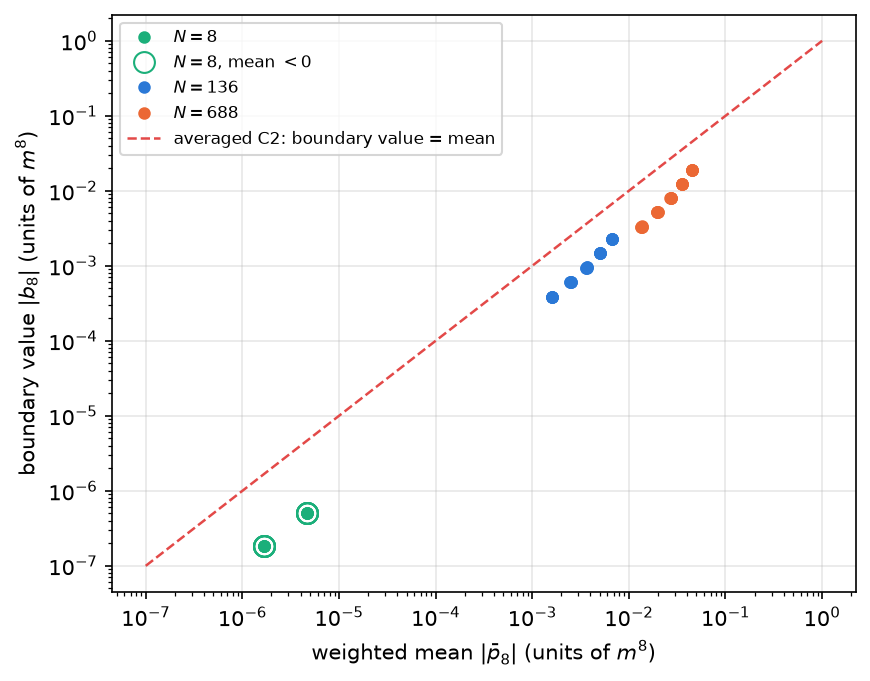

Figure 17b.4 saved as Revision/textbook/figures/17b_4_brane_and_mean.png
PASS every point lies below the diagonal; mean of p8 < 0 only for N = 8, lambda > 0


In [16]:
N_COLOURS = {8: "#1baf7a", 136: "#2a78d6", 688: "#eb6834"}
fig, ax = plt.subplots(figsize=(6.4, 5.0))
for n, colour in N_COLOURS.items():
    for positive in (True, False):
        ids = [sid for sid in nonzero if sid.startswith(f"N{n}_")
               and (mean_p8[sid] > 0) == positive]  # one sign at a time
        if not ids:
            continue
        ax.loglog([abs(mean_p8[sid]) for sid in ids],
                  [abs(boundary[sid]) for sid in ids], "o",
                  ms=5 if positive else 10,  # rings around the mirror states
                  color=colour, mfc=colour if positive else "none",
                  label=f"$N = {n}$" + ("" if positive else ", mean $< 0$"))
line = np.array([1e-7, 1.0])  # the range of the diagonal
ax.loglog(line, line, "--", color="#e34948", lw=1.2,
          label="averaged C2: boundary value = mean")
ax.set_xlabel("weighted mean $|\\bar p_8|$ (units of $m^8$)")
ax.set_ylabel("boundary value $|b_8|$ (units of $m^8$)")
ax.legend(fontsize=8, loc="upper left")
negative = sorted(sid for sid in nonzero if mean_p8[sid] < 0)  # mean of p8 < 0
say("states with a negative mean of p8: " + ", ".join(negative))
expected = sorted(sid for sid in nonzero if sid.startswith("N8_lamp"))
plotted = {sid: boundary[sid] / mean_p8[sid] for sid in nonzero}  # = R
save_figure(fig, "brane_and_mean",
            "The boundary value $b_8 = (p_8(0) - e^{-6HL}p_8(-L))/(1 - e^{-6HL})$ "
            "of the hidden-direction pressure against its weighted mean, for the "
            "70 recorded Kohn-Sham states with a nonzero source (logarithmic "
            "axes, units of $m^8$; colours: particle number; open rings: the "
            "$N = 8$ states with $\\lambda > 0$, whose mean and brane value of "
            "$p_8$ are negative; they enclose their partners with $-\\lambda$, "
            "which have the same absolute values; the 20 nonzero $N = 8$ states "
            "fall on only two places). By the integrated "
            "conservation law $b_8/\\bar p_8$ is exactly the averaged ratio $R$, "
            "and the averaged condition C2 holds only on the dashed diagonal; "
            "every state lies below it, with ratios between "
            f"{min(plotted.values()):.3f} and {max(plotted.values()):.3f}. The brane "
            "value alone gives the ratios "
            f"{min(brane_only.values()):.3f} to {max(brane_only.values()):.3f}: for "
            "the $N = 8$ states the tip term supplies about a third of $R$.")
check(negative == expected and all(0.0 < plotted[sid] < 1.0 for sid in nonzero),
      "every point lies below the diagonal; mean of p8 < 0 only for N = 8, "
      "lambda > 0")

## 12. The time direction: energy exchange and condition C3

The $x_4$ law of section 9 for a source that does not depend on $x_8$ reads
$\rho' = -3a_4'(p_3 - p_t)$. In words: when 3-space inflates ($a_4' > 0$) a
3-space pressure $p_3$ takes energy out of the source, and when the extra times
deflate an extra-time pressure $p_t$ puts energy in. For the linear member
$a_4' = AH \neq 0$, so a constant $\rho$ (part of C3) holds exactly when
$p_3 = p_t$ (another part of C3).

The $a_4$ equations know this. Write the constraint as
$\mathcal C = \sum_k\alpha_kE_{(k)}{}^{x_4}{}_{x_4} + \Lambda + \kappa\rho = 0$
and the evolution equation as $\mathcal E = a_4''F - \kappa(p_3 - p_t) = 0$. The
left-hand side of $\mathcal C$ depends on $x_4$ only through $a_4'$, so by the
chain rule $d\mathcal C/dx_4 = (\partial\mathcal C/\partial a_4')\,a_4'' +
\kappa\rho'$. The next cell inserts the record's Lovelock components and $F$,
uses $\rho' = -3a_4'(p_3 - p_t)$, and checks
$d\mathcal C/dx_4 = 3a_4'\,\mathcal E$ for all couplings $\alpha_1, \alpha_2,
\alpha_3$. Along the linear member ($a_4'' = 0$) this gives
$d\mathcal C/dx_4 = -3\kappa AH(p_3 - p_t)$: the constraint can hold at all
times only if $p_3 = p_t$.

In [17]:
ad1, ad2 = sp.symbols("ad1 ad2", real=True)  # a4' and a4''
alpha = sp.symbols("alpha1:4", real=True)  # the Lovelock couplings
kappa, p3s, pts = sp.symbols("kappa p3 pt", real=True)  # kappa and the pressures
LOCALS = {"ad1": ad1, "ad2": ad2, "H": H, "alpha1": alpha[0], "alpha2": alpha[1],
          "alpha3": alpha[2]}


def parse(text):
    """A formula of the record (Wolfram Language text) as a sympy expression."""
    return sp.sympify(text.replace("^", "**"), locals=LOCALS)


E44 = sum(alpha[k - 1] * parse(equations["lovelockTensors"][f"E{k}"]["x4x4"]["input"])
          for k in (1, 2, 3))  # sum_k alpha_k E_(k)^x4_x4
F = parse(equations["generalSource"]["evolution_F"]["input"])
rho_dot = -3 * ad1 * (p3s - pts)  # the x4 conservation law
constraint_dot = sp.diff(E44, ad1) * ad2 + kappa * rho_dot  # chain rule
evolution = ad2 * F - kappa * (p3s - pts)
say(f"d/d(a4') of the x4 component: {sp.factor(sp.diff(E44, ad1))}")
say(f"3 a4' F: {sp.factor(3 * ad1 * F)}")
reproduces(sp.expand(constraint_dot - 3 * ad1 * evolution) == 0,
           "PROVED: dC/dx4 = 3 (da4/dx4) times the evolution equation, any alpha_k",
           WL_A4, ["constraint_propagation_bianchi"])
linear = sp.expand(constraint_dot.subs({ad2: 0, ad1: sp.Symbol("A") * H}))
say(f"along the linear member a4 = A H x4: dC/dx4 = {sp.factor(linear)}")

d/d(a4') of the x4 component: 6*ad1*(360*H**4*alpha3 + 432*H**2*ad1**2*alpha3 -
    40*H**2*alpha2 + 360*ad1**4*alpha3 - 24*ad1**2*alpha2 + alpha1)
3 a4' F: 6*ad1*(360*H**4*alpha3 + 432*H**2*ad1**2*alpha3 - 40*H**2*alpha2 +
    360*ad1**4*alpha3 - 24*ad1**2*alpha2 + alpha1)
PASS PROVED: dC/dx4 = 3 (da4/dx4) times the evolution equation, any alpha_k
     reproduces Revision/field_equations_a4/reports/wolfram-a4-report.json, check
    constraint_propagation_bianchi
along the linear member a4 = A H x4: dC/dx4 = -3*A*H*kappa*(p3 - pt)


For the Kohn-Sham gas only the integrated version of the $x_4$ law is recorded
(the cell after the next two shows why: point by point it fails):
$dE/da_{4,0} = -3\left(\int p_3 - \int p_t\right)$ with the total energy
$E = \int\rho$ (the Rust solver checks it with tiny steps of $a_4$). The recorded
slices are $0.5$ apart, so we can test it with Simpson's rule over the whole
history: $E(2) - E(0)$ must equal the integral of $-3(\int p_3 - \int p_t)$ from
$0$ to $2$. This is fair only if each state is followed continuously from slice
to slice (no level crosses the Fermi level); the record of the history lists no
such crossing. The next cell does this for all 15 series (three particle numbers,
five couplings).

In [18]:
history = read_json("Revision/kohn_sham/results/adiabatic/history.json")
no_crossing = all(not series["fermiLevelCrossings"] for series in history["series"])
TAGS = ["lamm2", "lamm1", "lam0", "lamp1", "lamp2"]  # the five couplings
simpson_error, energies, drives = {}, {}, {}
for n in (8, 136, 688):
    for tag in TAGS:
        ids = [f"N{n}_{tag}_{s}" for s in SLICES]
        E = np.array([number(sid, "int_rho") for sid in ids])  # E at the slices
        drive = np.array([-3 * (number(sid, "int_p3") - number(sid, "int_p_t"))
                          for sid in ids])  # dE/da4 at the slices
        simpson = 0.5 / 3 * (drive[0] + 4 * drive[1] + 2 * drive[2]
                             + 4 * drive[3] + drive[4])  # step 0.5, from 0 to 2
        energies[(n, tag)], drives[(n, tag)] = E, drive
        change = E[-1] - E[0]
        simpson_error[(n, tag)] = (abs(simpson - change) / abs(change)
                                   if change != 0.0 else abs(simpson))
moving = [key for key in simpson_error if key[0] != 8]
largest = max(simpson_error[key] for key in moving)
unchanged = all(np.all(energies[(8, tag)] == energies[(8, tag)][0])
                and np.all(drives[(8, tag)] == 0.0) for tag in TAGS)
for n in (136, 688):
    E, error = energies[(n, "lam0")], simpson_error[(n, "lam0")]
    say(f"N = {n}, lambda = 0: E(0) = {E[0]:.6g}, E(2) = {E[-1]:.6g}, "
        f"change {E[-1] - E[0]:.6g}, relative Simpson error {error:.1e}")
report("largest relative Simpson error, N = 136 and 688", f"{largest:.1e}")
reproduces(no_crossing and largest < 1e-3 and unchanged,
           "E(2) - E(0) = integral of -3 (int p3 - int p_t) along the history",
           KS_RUST, ["emt_energy_change_dE_da4"])

N = 136, lambda = 0: E(0) = 80.2822, E(2) = 12.4451, change -67.8372, relative Simpson
    error 2.1e-04
N = 688, lambda = 0: E(0) = 680.441, E(2) = 110.387, change -570.055, relative Simpson
    error 2.2e-04
RESULT largest relative Simpson error, N = 136 and 688 = 2.2e-04
PASS E(2) - E(0) = integral of -3 (int p3 - int p_t) along the history
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    emt_energy_change_dE_da4


The next cell draws the energy along the history for $N = 136$ and $N = 688$
with $\lambda = 0$, divided by its value at $a_{4,0} = 0$ (left), together with
the values predicted from $E(0)$ by Simpson's rule (crosses at $a_{4,0} = 1$ and
$2$) and the constant energy that C3 would need; and the relative Simpson error
of all ten moving series (right). The $N = 8$ series do not move: their
pressures obey $p_3 = p_t$ exactly, so their energy is the same at every slice.

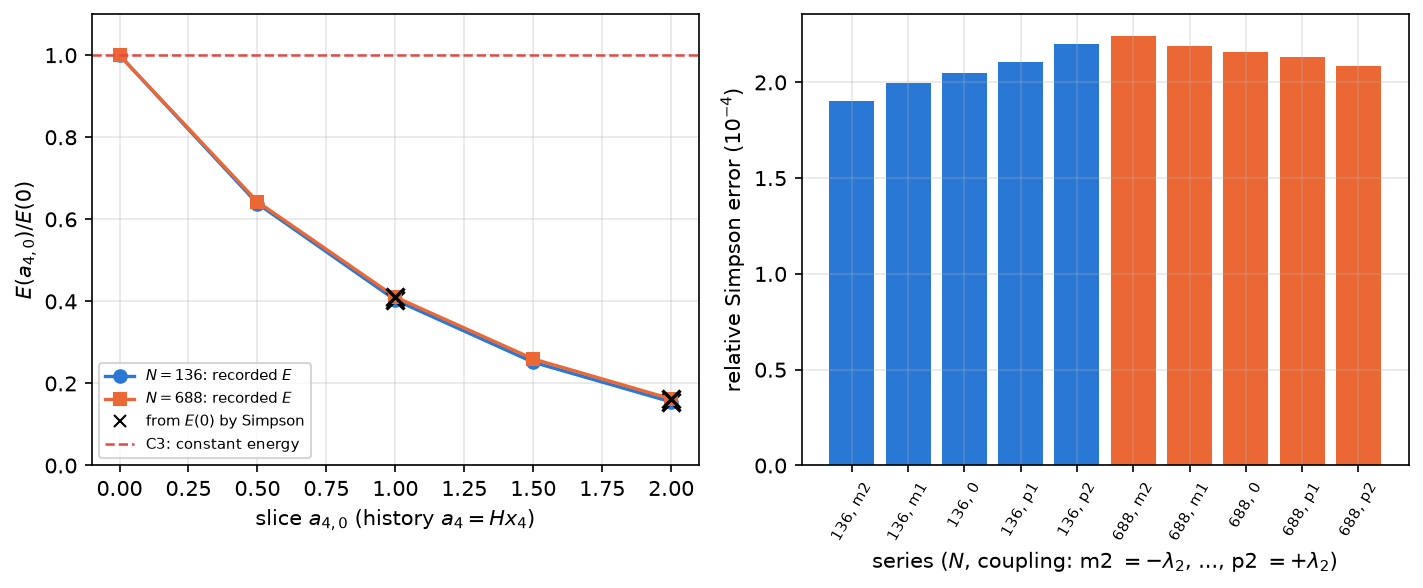

Figure 17b.5 saved as Revision/textbook/figures/17b_5_energy_exchange.png


In [19]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9.6, 4.0))
slice_values = np.array(list(SLICES.values()))
for n, marker in ((136, "o"), (688, "s")):
    E, drive = energies[(n, "lam0")], drives[(n, "lam0")]
    to_one = E[0] + 0.5 / 3 * (drive[0] + 4 * drive[1] + drive[2])  # 0 to 1
    to_two = to_one + 0.5 / 3 * (drive[2] + 4 * drive[3] + drive[4])  # 1 to 2
    left.plot(slice_values, E / E[0], marker=marker, color=N_COLOURS[n], lw=1.6,
              label=f"$N = {n}$: recorded $E$")
    left.plot([1.0, 2.0], [to_one / E[0], to_two / E[0]], "x", color="black",
              ms=9, mew=1.6)
left.plot([], [], "x", color="black", label="from $E(0)$ by Simpson")
left.axhline(1.0, color="#e34948", ls="--", lw=1.2, label="C3: constant energy")
left.set_xlabel("slice $a_{4,0}$ (history $a_4 = Hx_4$)")
left.set_ylabel("$E(a_{4,0}) / E(0)$")
left.set_ylim(0.0, 1.1)
left.legend(fontsize=7, loc="lower left")
keys = [(n, tag) for n in (136, 688) for tag in TAGS]
labels = [f"{n}, {tag[3:]}" for n, tag in keys]  # N and the coupling tag
right.bar(range(len(keys)), [simpson_error[key] * 1e4 for key in keys],
          color=[N_COLOURS[n] for n, _ in keys])
right.set_xticks(range(len(keys)), labels, rotation=60, fontsize=7)
right.set_xlabel("series ($N$, coupling: m2 $= -\\lambda_2$, ..., p2 $= +\\lambda_2$)")
right.set_ylabel("relative Simpson error ($10^{-4}$)")
fig.tight_layout()
fall = [energies[(n, "lam0")][0] / energies[(n, "lam0")][-1] for n in (136, 688)]
save_figure(fig, "energy_exchange",
            "Left: the total energy $E = \\int\\rho$ of the Kohn-Sham states with "
            "$\\lambda = 0$ along the history $a_4 = Hx_4$, divided by its value at "
            "$a_{4,0} = 0$ (circles $N = 136$, squares $N = 688$; pure numbers), "
            "the values predicted from $E(0)$ by integrating "
            "$dE/da_4 = -3(\\int p_3 - \\int p_t)$ with Simpson's rule (crosses), "
            "and the constant energy that condition C3 of the linear member needs "
            f"(dashed). The energy falls by factors of {fall[0]:.2f} and "
            f"{fall[1]:.2f}: as 3-space inflates and the extra times deflate, the "
            "gas with $p_3 > p_t = 0$ gives up energy. Right: the relative error of "
            "Simpson's rule for $E(2) - E(0)$ in all ten moving series, in units of "
            f"$10^{{-4}}$ (largest ${tex_number(largest)}$): the energy-change law "
            "holds to "
            "the accuracy of the five slices.")

The energy law was tested above for the energy $E$ of the whole patch. Does it
also hold point by point, $\partial\rho/\partial a_4 = -3(p_3 - p_t)$ at every
$y$ (with $a_4' = H$ along the history)? The next cell takes the ten moving
series, estimates $\partial\rho/\partial a_4$ at the slice $a_{4,0} = 1$ at every
grid point with the fourth-order difference of section 3 in the variable $a_4$
(step $0.5$, the five slices), and compares it with $-3(p_3 - p_t)$ of that
slice: at three points, and integrated over the patch with the weight $e^{6Hy}$
(Simpson's rule in $y$). The record says that the instantaneous states carry no
energy flux along $y$ ($T^{x_4}{}_y = 0$), so nothing moves energy from one value
of $y$ to another: the total can be right while the pointwise law fails.

In [20]:
def change_with_a4(n, tag):
    """d rho / d a4 at the slice a4,0 = 1 at every y (fourth order, step 0.5)."""
    v = [profiles[f"N{n}_{tag}_{s}"]["rho"] for s in SLICES]  # rho at 5 slices
    return (v[0] - 8 * v[1] + 8 * v[3] - v[4]) / (12 * 0.5)


weight = np.exp(6 * H_value * y)  # the volume weight e^(6Hy) on the grid


def patch_integral(values):
    """Simpson's rule for the integral of e^(6Hy) times values over the patch."""
    f = weight * values
    return h / 3 * (f[0] + f[-1] + 4 * f[1:-1:2].sum() + 2 * f[2:-1:2].sum())


tip_ratio, integral_gap = {}, {}
for n, tag in moving:
    middle = profiles[f"N{n}_{tag}_a10"]  # the slice a4,0 = 1
    left_side = change_with_a4(n, tag)  # d rho / d a4 at every y
    right_side = -3 * (middle["p3"] - middle["p_t"])  # what the law needs there
    tip_ratio[(n, tag)] = float(left_side[0] / right_side[0])  # at y = -3
    integral_gap[(n, tag)] = float(abs(patch_integral(left_side)
                                       / patch_integral(right_side) - 1.0))
slice_one = profiles["N136_lam0_a10"]
rate136 = change_with_a4(136, "lam0")
for index, place in ((0, "-3 (tip)"), (75, "-1.5"), (150, "0 (brane)")):
    needed = -3 * (slice_one["p3"][index] - slice_one["p_t"][index])
    say(f"N = 136, lambda = 0, a4,0 = 1, y = {place}: d rho/d a4 = "
        f"{rate136[index]:.4g}, -3 (p3 - p_t) = {needed:.4g}")
report("ratio of the two sides at the tip, 10 series",
       f"{min(tip_ratio.values()):.3f} to {max(tip_ratio.values()):.3f}")
report("largest relative difference of the two patch integrals",
       f"{max(integral_gap.values()):.1e}")
reproduces(all(r < 0.0 for r in tip_ratio.values())
           and max(integral_gap.values()) < 5e-3,
           "the x4 law fails point by point, holds for the energy of the patch",
           KS_PY, ["emt_x4_component"])

N = 136, lambda = 0, a4,0 = 1, y = -3 (tip): d rho/d a4 = 82.97, -3 (p3 - p_t) = -474.8
N = 136, lambda = 0, a4,0 = 1, y = -1.5: d rho/d a4 = -0.4505, -3 (p3 - p_t) = -1.497
N = 136, lambda = 0, a4,0 = 1, y = 0 (brane): d rho/d a4 = -0.002068, -3 (p3 - p_t) =
    -0.001174
RESULT ratio of the two sides at the tip, 10 series = -0.327 to -0.106
RESULT largest relative difference of the two patch integrals = 1.3e-03
PASS the x4 law fails point by point, holds for the energy of the patch
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check emt_x4_component


## 13. The equations averaged over the hidden direction (an approximation)

No recorded state meets C1, so the $a_4$ equations cannot hold point by point
with the Kohn-Sham source. The Revision record in the folder
`Revision/field_equations_a4/ks_source` asks the next weaker question: multiply
every field equation by the volume weight $e^{6Hy}$ and integrate it over the
patch. Because the left-hand sides do not depend on $y$, each one becomes the
same equation with the source replaced by its weighted average $\bar X$ (its
**moment**). These moment equations are NECESSARY conditions: every exact
solution obeys them. The next cell computes the averages
$\bar X = \int X / (2\,\mathrm{Vol}_7 W)$, $W = (1 - e^{-6HL})/(6H)$, of every
state from the record's integrals, compares $\bar\rho$ with the record's table of
averages, and evaluates the averaged C2 (the $x_1 + x_5 - 2x_8$ moment) through
its relative defect
$|\bar p_3 + \bar p_t - 2\bar p_8|/(|\bar p_3| + |\bar p_t| + 2|\bar p_8|)$,
which is $0$ when the averaged C2 holds.

In [21]:
MOMENTS = "Revision/field_equations_a4/ks_source/results/ks-source-moments.csv"
W = (1 - tip_weight) / (6 * H_value)  # the integral of e^(6Hy) over the patch


def mean(sid, column):
    """The weighted average of a column, from the record's integral."""
    return number(sid, f"int_{column}") / (2 * VOL7 * W)


with repository_file(MOMENTS).open(encoding="utf-8", newline="") as handle:
    moments = {row["id"]: row for row in csv.DictReader(handle)}
agree = max(abs(mean(sid, "rho") / float(moments[sid]["rho_bar"]) - 1.0)
            for sid in nonzero)
defect = {}
for sid in nonzero:
    p3b, ptb, p8b = (mean(sid, column) for column in ("p3", "p_t", "p8"))
    defect[sid] = abs(p3b + ptb - 2 * p8b) / (abs(p3b) + abs(ptb) + 2 * abs(p8b))
low, high = min(defect, key=defect.get), max(defect, key=defect.get)
report("largest relative difference of rho_bar from the record", f"{agree:.1e}")
report("defect of the averaged C2",
       f"{defect[low]:.6g} ({low}) to {defect[high]:.6g}")
detail = record_entry(KS_SOURCE, "C1_averaged_algebraic_condition_fails")["detail"]
reproduces(agree < 1e-6
           and f"[{defect[low]:.6g} ({low}), {defect[high]:.6g}]" in detail,
           "the averaged C2 fails by a defect of order 1 in all 70 states",
           KS_SOURCE, ["C1_averaged_algebraic_condition_fails"])

RESULT largest relative difference of rho_bar from the record = 6.7e-08
RESULT defect of the averaged C2 = 0.414086 (N688_lamm2_a00) to 0.806379
PASS the averaged C2 fails by a defect of order 1 in all 70 states
     reproduces Revision/field_equations_a4/ks_source/reports/ks-source-a4.json, check
    C1_averaged_algebraic_condition_fails


Which moment equations can hold together? The Revision record proves (checks
`A4_constraint_propagation_with_averaged_source`, `C2_averaged_energy_relation`
and `C3_x8_moment_inconsistent_with_history`) that the $x_4$ moment (the
constraint) and the $x_1 - x_5$ moment (the evolution equation) are consistent,
because the averages obey $d\bar\rho/da_4 = -3(\bar p_3 - \bar p_t)$; every set
that contains the $x_8$ moment is not. Keeping the consistent pair and dropping
the $x_8$ and $x_1 + x_5 - 2x_8$ moments is an APPROXIMATION; its error is the
dropped residuals, which the record finds to be of order 1. In Einstein gravity
the constraint is $3a_4'^2 + 21H^2 + \Lambda = -\kappa\bar\rho(a_4)$. At $a_4 = 0$
with the initial rate $a_4'(0) = H$ it fixes $\Lambda = -24H^2 - \sigma_0H^2$,
where $\sigma_0 = \kappa\bar\rho(0)/H^2$ is the source strength; subtracting the
two gives the **first integral**

$$\left(\frac{a_4'}{H}\right)^2 = 1 + \frac{\sigma_0}{3}\left(1 -
\frac{\bar\rho(a_4)}{\bar\rho(0)}\right).$$

The next cell evaluates it for the series $N = 136$, $\lambda = 0$: at the slice
$a_4 = 2$ for $\sigma_0 = 10, 1, -1$; and between the slices with the cubic
Hermite interpolant of $\bar\rho$ whose slopes are the exact
$-3(\bar p_3 - \bar p_t)$, to find by bisection the turning point where $a_4'$
reaches $0$ for $\sigma_0 = -10$ and for $\Lambda = 0$ ($\sigma_0 = -24$). It
compares every number with the record's table of integrated cases.

In [22]:
CASES = "Revision/field_equations_a4/ks_source/results/ks-source-a4-cases.csv"
series = "N136_lam0"  # the canonical series
ids = [f"{series}_{s}" for s in SLICES]  # its five states
rho_bar = np.array([mean(sid, "rho") for sid in ids])
rho_slope = np.array([-3 * (mean(sid, "p3") - mean(sid, "p_t")) for sid in ids])


def rho_between(a):
    """rho_bar(a4) between the slices: cubic Hermite with the exact slopes."""
    k = min(int(a / 0.5), 3)  # the interval [0.5 k, 0.5 k + 0.5] that holds a
    t = (a - 0.5 * k) / 0.5  # the position inside it, from 0 to 1
    return ((2 * t**3 - 3 * t**2 + 1) * rho_bar[k]
            + (t**3 - 2 * t**2 + t) * 0.5 * rho_slope[k]
            + (-2 * t**3 + 3 * t**2) * rho_bar[k + 1]
            + (t**3 - t**2) * 0.5 * rho_slope[k + 1])


def rate_squared(a, sigma0):
    """(a4'/H)^2 at a4 = a from the Einstein first integral, a4'(0) = H."""
    return 1.0 + sigma0 / 3.0 * (1.0 - rho_between(a) / rho_bar[0])


def turning_point(sigma0):
    """The a4 in [0, 0.5] where (a4'/H)^2 reaches 0, by bisection."""
    low_end, high_end = 0.0, 0.5
    for _ in range(60):  # each step halves the interval
        centre = (low_end + high_end) / 2
        if rate_squared(centre, sigma0) > 0.0:
            low_end = centre
        else:
            high_end = centre
    return low_end


with repository_file(CASES).open(encoding="utf-8", newline="") as handle:
    cases = {(row["gravity"], row["series"], row["case"]): row
             for row in csv.DictReader(handle)}
rate_gap, turn_gap, halts = 0.0, 0.0, {}
for sigma0 in (10, 1, -1):
    ours = rate_squared(2.0, sigma0) ** 0.5  # a4'/H at a4 = 2
    theirs = float(cases[("einstein", series, f"sigma0 = {sigma0}")]["rate_a20"])
    rate_gap = max(rate_gap, abs(ours / theirs - 1.0))
    say(f"sigma0 = {sigma0:3d}: a4'/H at a4 = 2 is {ours:.6g} (record {theirs:.6g})")
for sigma0, case in ((-10, "sigma0 = -10"), (-24, "Lambda = 0")):
    halts[sigma0] = turning_point(sigma0)
    theirs = float(cases[("einstein", series, case)]["a4_end"])
    turn_gap = max(turn_gap, abs(halts[sigma0] / theirs - 1.0))
    say(f"{case}: the deflation halts at a4 = {halts[sigma0]:.6g} "
        f"(record {theirs:.6g})")
reproduces(rate_gap < 1e-8, "Einstein first integral: a4'/H at a4 = 2 as recorded",
           KS_SOURCE, ["D2_einstein_first_integral"])
reproduces(turn_gap < 1e-6, "turning points for sigma0 = -10 and Lambda = 0",
           KS_SOURCE, ["D3_lambda_zero_cases_halt"])

sigma0 =  10: a4'/H at a4 = 2 is 1.95362 (record 1.95362)
sigma0 =   1: a4'/H at a4 = 2 is 1.1321 (record 1.1321)
sigma0 =  -1: a4'/H at a4 = 2 is 0.847549 (record 0.847549)
sigma0 = -10: the deflation halts at a4 = 0.397998 (record 0.397998)
Lambda = 0: the deflation halts at a4 = 0.149623 (record 0.149623)
PASS Einstein first integral: a4'/H at a4 = 2 as recorded
     reproduces Revision/field_equations_a4/ks_source/reports/ks-source-a4.json, check
    D2_einstein_first_integral
PASS turning points for sigma0 = -10 and Lambda = 0
     reproduces Revision/field_equations_a4/ks_source/reports/ks-source-a4.json, check
    D3_lambda_zero_cases_halt


The next cell draws the first integral: $a_4'/H$ against $a_4$ over the computed
range $0 \le a_4 \le 2$ for five source strengths, with the turning points and the
constant rate of the linear member $a_4 = Hx_4$ (the history on which the
Kohn-Sham states were computed).

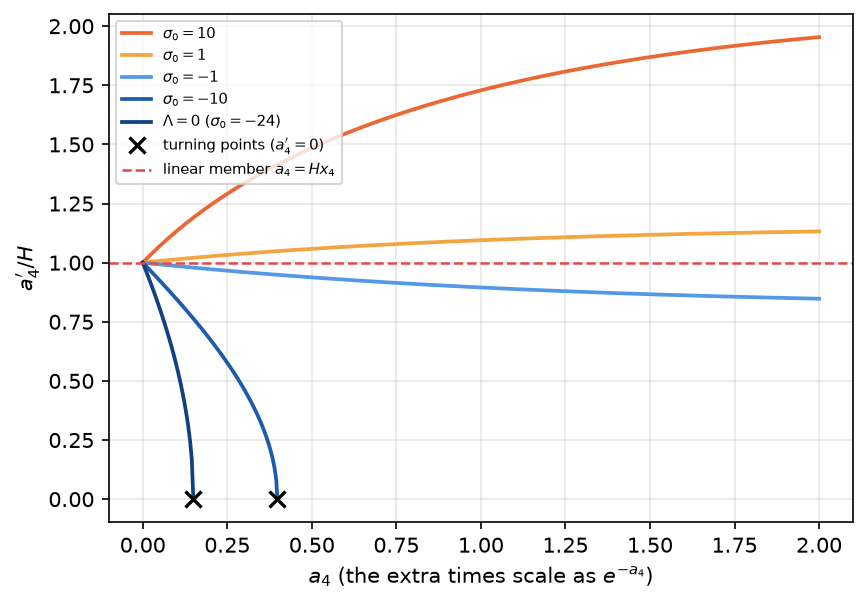

Figure 17b.6 saved as Revision/textbook/figures/17b_6_first_integral.png


In [23]:
grid = np.linspace(0.0, 2.0, 401)  # a4 from 0 to 2 in steps of 0.005
STRENGTHS = [(10, "#eb6834"), (1, "#f2a541"), (-1, "#5598e7"), (-10, "#1c5cab"),
             (-24, "#104281")]  # sigma0 and its colour
fig, ax = plt.subplots(figsize=(6.4, 4.4))
for sigma0, colour in STRENGTHS:
    values = np.array([rate_squared(a, sigma0) for a in grid])
    keep = values >= 0.0  # a4'^2 cannot be negative: a4 turns back there
    label = ("$\\Lambda = 0$ ($\\sigma_0 = -24$)" if sigma0 == -24
             else f"$\\sigma_0 = {sigma0}$")
    x_values, rates = grid[keep], np.sqrt(values[keep])
    if sigma0 in halts:  # end the curve exactly at its turning point
        x_values, rates = np.append(x_values, halts[sigma0]), np.append(rates, 0.0)
    ax.plot(x_values, rates, color=colour, lw=1.8, label=label)
ax.plot(list(halts.values()), [0.0, 0.0], "kx", ms=8, mew=1.6,
        label="turning points ($a_4' = 0$)")
ax.axhline(1.0, color="#e34948", ls="--", lw=1.2,
           label="linear member $a_4 = Hx_4$")
ax.set_xlabel("$a_4$ (the extra times scale as $e^{-a_4}$)")
ax.set_ylabel("$a_4'/H$")
ax.legend(fontsize=7, loc="upper left")
end_rates = {s: rate_squared(2.0, s) ** 0.5 for s in (10, 1, -1)}
save_figure(fig, "first_integral",
            "The rate $a_4'/H$ of the deflation of the extra times against $a_4$ "
            "(pure numbers), from the first integral of the averaged $a_4$ "
            "equations of Einstein gravity with the Kohn-Sham source $N = 136$, "
            "$\\lambda = 0$ (an APPROXIMATION: the $x_8$ moments are dropped), "
            "initial rate $a_4'(0) = H$, for the source strengths "
            "$\\sigma_0 = \\kappa\\bar\\rho(0)/H^2 = 10, 1, -1, -10$ and for "
            "$\\Lambda = 0$ ($\\sigma_0 = -24$). The dashed line is the constant "
            "rate of the history $a_4 = Hx_4$. A positive $\\sigma_0$ speeds the "
            f"deflation up ($a_4'/H = {end_rates[10]:.3f}$ and "
            f"${end_rates[1]:.3f}$ at $a_4 = 2$), a negative one slows it down "
            f"(${end_rates[-1]:.3f}$ for $\\sigma_0 = -1$); for $\\sigma_0 = -10$ "
            f"and for $\\Lambda = 0$ it halts at $a_4 = {halts[-10]:.3f}$ and "
            f"${halts[-24]:.3f}$ (crosses). The source does not create the "
            "deflation: the initial rate is chosen.")

## 14. The last check

The last cell checks that the six figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [24]:
figure_names = ["eight_gammas", "slope_identity", "difference_order",
                "brane_and_mean", "energy_exchange", "first_integral"]
paths = [output_file(f"{FIGURE_FOLDER}/17b_{k}_{name}.png")
         for k, name in enumerate(figure_names, 1)]
check(all(path.is_file() for path in paths),
      "every figure file of this notebook exists")
all_checks_passed()

PASS every figure file of this notebook exists
ALL 20 CHECKS PASSED (notebook 17b)


## 15. What this notebook showed

- COMPUTED and exact: the Kohn-Sham source rests on the author's eight REAL
  $16 \times 16$ gamma matrices (signed permutation matrices with the Clifford
  relation for all 64 pairs); the Rust solver read exactly this file (equal sha256
  digits).
- PROVED (sympy, equal to the $a_4$ record and to the Kohn-Sham theory record):
  in the author's metric a diagonal source is conserved when
  $\rho' = -3a_4'(p_3 - p_t)$ (time direction) and
  $p_8' + 6Hp_8 = 3H(p_3 + p_t)$ (hidden direction, coordinate $y$).
- PROVED: for a conserved source the violation of C2 is
  $p_3 + p_t - 2p_8 = p_8'(y)/(3H)$, so C2 is the statement "$p_8$ is flat"; and
  $d\mathcal C/dx_4 = 3a_4'\,\mathcal E$, so the linear member needs $p_3 = p_t$
  and a constant $\rho$.
- COMPUTED (the 75 recorded states): the Kohn-Sham states obey the conservation
  law of the hidden direction point by point (to about $10^{-4}$ of max|T| with
  fourth-order differences of step 0.02, the error falling with the fourth power
  of the step) and integrated over the patch (to about $10^{-11}$). The energy
  law of the time direction holds for the energy of the whole patch along the
  history (Simpson's rule, to about $2 \times 10^{-4}$), but NOT point by point:
  at the tip its two sides even have opposite signs. The instantaneous states
  carry no energy flux along $y$; a genuinely time-dependent state would need one
  ($q_{84} \neq 0$), and C1 forbids it.
- Hence the Kohn-Sham source is NOT ADMISSIBLE: its $p_8$ is far from flat (so
  C1 and C2 fail together) and its $p_3 > p_t$ makes its energy change along the
  history (so C3 fails). Conservation is necessary for a source of the $a_4$
  equations, not sufficient. The history $a_4 = Hx_4$ remains a PRESCRIBED
  BACKGROUND (ASSUMED), and the Kohn-Sham gas a test field without
  back-reaction.
- COMPUTED within an ASSUMED approximation (the Revision record `ks_source`,
  reproduced): averaged over the hidden direction, C2 still fails by a defect of
  order 1. Keeping only the consistent pair of moment equations (constraint and
  evolution) gives the first integral; in Einstein gravity the Kohn-Sham source
  changes a deflation that is
  already there by a bounded amount, and with $\Lambda = 0$ it halts it at
  $a_4 \approx 0.15$. It does not start or select the exponential deflation of
  the extra times: the initial rate is chosen.
- NOT shown (OPEN): what metric the Kohn-Sham gas would produce with
  back-reaction; whether any state of dirac16complex is an admissible source of
  the author's metric.